# SSQueezePy Coherent Mode Extraction for Creepmeter Data

This notebook demonstrates how to use **synchrosqueezed CWT** (SSQ-CWT) to extract and reconstruct
individual coherent modes from creepmeter displacement data:

- **Tidal** (O1, K1, M2, S2): 0.8–2.2 cycles/day
- **Multi-day** (slow-slip, weather): 0.05–0.5 cycles/day
- **Seasonal/trend**: < 0.01 cycles/day

### Why SSQ over raw CWT?

Synchrosqueezing **reassigns** blurry scalogram energy to sharp instantaneous-frequency lines.
This makes ridge extraction and component separation far more precise than working with
the raw CWT, where energy smears across many scale rows.

## Cell 1 – Imports and data loading

Loaded 154031 samples, 1069.7 days, fs = 1.666667e-03 Hz
NaN-filled: 0 samples


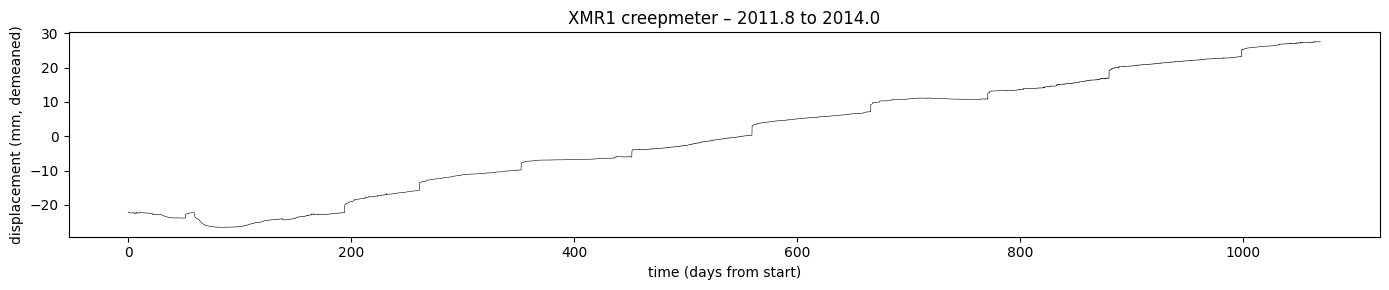

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ssqueezepy import ssq_cwt, issq_cwt, extract_ridges
from ssqueezepy.toolkit import lin_band

# ---- data-loading functions (from test_Wavelets.ipynb) ----

def read_usgs_10min_file(filename):
    columns = ['Year', 'Julian_Day', 'Displacement', 'Quality']
    dtype = {'Year': str, 'Julian_Day': float, 'Displacement': float, 'Quality': str}
    data = pd.read_csv(
        filename, sep=r"\s+", engine="python",
        header=None, names=columns, dtype=dtype,
    )
    data['Displacement'] = pd.to_numeric(data['Displacement'], errors='coerce')
    return data

def select_date_range(data, start_date, end_date):
    start_year, start_julian = map(float, start_date.split('.'))
    end_year, end_julian = map(float, end_date.split('.'))
    data_years = data['Year'].astype(float)
    data_julian = data['Julian_Day'].values
    mask = (
        ((data_years > start_year) | ((data_years == start_year) & (data_julian >= start_julian)))
        & ((data_years < end_year) | ((data_years == end_year) & (data_julian <= end_julian)))
    )
    return data[mask].reset_index(drop=True)

def create_signal(data):
    years = data['Year'].astype(int).values
    julian_days = data['Julian_Day'].values - 1
    amplitude = data['Displacement'].values
    time = years + (julian_days / (365 + (years % 4 == 0).astype(int)))
    return time, amplitude

# ---- load xmr1, 2011.8–2014.0 ----

filename = '/Users/amasaryk/projects/Creep/Cleaned_data_creep/xmr1.10min'
data = read_usgs_10min_file(filename)
selected = select_date_range(data, '2011.8', '2014.0')
time_yr, amplitude = create_signal(selected)

# clean NaNs, remove mean
x = amplitude.astype(np.float64)
nan_mask = np.isnan(x)
x[nan_mask] = np.nanmean(x)
x = x - np.mean(x)

# sampling
dt = 10 * 60          # 10 minutes in seconds
fs = 1.0 / dt         # Hz
N = len(x)
t_days = np.arange(N) * dt / 86400.0

print(f"Loaded {N} samples, {t_days[-1]:.1f} days, fs = {fs:.6e} Hz")
print(f"NaN-filled: {nan_mask.sum()} samples")

plt.figure(figsize=(14, 3))
plt.plot(t_days, x, linewidth=0.4, color='k')
plt.xlabel('time (days from start)')
plt.ylabel('displacement (mm, demeaned)')
plt.title('XMR1 creepmeter – 2011.8 to 2014.0')
plt.tight_layout()
plt.show()

## Sawtooth wave test — do inherent harmonics appear in SSQ-CWT?

Generate a **perfect sawtooth** via `scipy.signal.sawtooth` (piecewise-linear, no Fourier construction)
and run the same SSQ-CWT pipeline. A pure sawtooth at frequency f₀ has harmonics at 2f₀, 3f₀, 4f₀, …
with amplitudes ∝ 1/n. If the wavelet transform is working correctly these should appear as distinct
horizontal bands in the scalogram.

In [2]:
# ---- Perfect sawtooth wave + SSQ-CWT vs CWT ----
from scipy.signal import sawtooth as _sawtooth
from ssqueezepy import ssq_cwt, Wavelet
from ssqueezepy.visuals import imshow

# ---- parameters ----
f0_cpd = 1.0          # fundamental frequency in cycles/day
duration_days = 60     # total duration
dt_saw = 10 * 60       # 10-minute sampling (same as creepmeter)
fs_saw = 1.0 / dt_saw  # Hz
wavelet_saw = 'gmw'    # wavelet to use

N_saw = int(duration_days * 86400 / dt_saw)
t_saw = np.arange(N_saw) * dt_saw                # seconds
t_saw_days = t_saw / 86400.0                      # days

# scipy.signal.sawtooth: piecewise linear, NOT built from Fourier series
f0_hz = f0_cpd / 86400.0
x_saw = _sawtooth(2 * np.pi * f0_hz * t_saw, width=1)  # range [-1, 1]

# Get center frequency from the actual wavelet being used
wavelet_obj_saw = Wavelet(wavelet_saw)
mu_saw = wavelet_obj_saw.wc_ct
print(f"Sawtooth: f0 = {f0_cpd} cpd, N = {N_saw}, duration = {duration_days} days")
print(f"Wavelet: {wavelet_saw}, mu = {mu_saw:.4f}")
print(f"Expected harmonics at: {', '.join(f'{k*f0_cpd:.1f}' for k in range(1, 9))} cpd")

# ---- SSQ-CWT (log scales) ----
nv_saw = 16
Tx_saw, Wx_saw, _, scales_saw = ssq_cwt(
    x_saw, wavelet=wavelet_saw, scales='log:maximal',
    nv=nv_saw, fs=fs_saw, padtype='reflect', maprange='maximal',
)
freq_cpd_saw = mu_saw * fs_saw / (2 * np.pi * scales_saw) * 86400.0

# ---- Plot: signal + SSQ scalogram + CWT scalogram ----
fig, axes = plt.subplots(3, 1, figsize=(15, 14))

# time-domain signal
axes[0].plot(t_saw_days[:1000], x_saw[:1000], 'k-', linewidth=0.6)
axes[0].set_xlabel('time (days)')
axes[0].set_ylabel('amplitude')
axes[0].set_title(f'Sawtooth wave — f₀ = {f0_cpd} cpd (first {t_saw_days[999]:.1f} days)')

# SSQ scalogram
imshow(Tx_saw, abs=1, cmap='turbo', ax=axes[1], fig=fig, show=0,
       yticks=freq_cpd_saw, ylabel='freq (cpd)',
       xticks=t_saw_days, xlabel='time (days)',
       title=f'SSQ-CWT ({wavelet_saw}) — synchrosqueezed')

# CWT scalogram
imshow(Wx_saw, abs=1, cmap='turbo', ax=axes[2], fig=fig, show=0,
       yticks=freq_cpd_saw, ylabel='freq (cpd)',
       xticks=t_saw_days, xlabel='time (days)',
       title=f'CWT ({wavelet_saw}) — raw scalogram')

# annotate expected harmonic lines on both scalograms
for ax_i in [axes[1], axes[2]]:
    for k in range(1, 9):
        fk = k * f0_cpd
        if freq_cpd_saw.min() <= fk <= freq_cpd_saw.max():
            row = np.argmin(np.abs(freq_cpd_saw - fk))
            ax_i.axhline(row, color='white', linewidth=0.7, linestyle='--', alpha=0.6)
            ax_i.text(5, row - 2, f'{k}f₀={fk:.0f}', color='white', fontsize=8)

fig.tight_layout()
plt.show()

# ---- Print harmonic power (SSQ) ----
power_per_row = np.mean(np.abs(Tx_saw)**2, axis=1)
print(f"\n{'Harmonic':<10} {'cpd':<8} {'Row':<6} {'Power':<12} {'Relative':<10}")
print("-" * 46)
p_fund = None
for k in range(1, 9):
    fk = k * f0_cpd
    if freq_cpd_saw.min() <= fk <= freq_cpd_saw.max():
        row = np.argmin(np.abs(freq_cpd_saw - fk))
        r_lo, r_hi = max(0, row - 2), min(len(power_per_row), row + 3)
        p = power_per_row[r_lo:r_hi].sum()
        if k == 1:
            p_fund = p
        rel = p / p_fund if p_fund else 0
        print(f"{k}f₀        {fk:<8.1f} {row:<6} {p:<12.4e} {rel:<10.3f}")

: 

STFT: 289 freq bins, 31 time frames
Freq resolution: 0.2500 cpd
Window: 576 samples = 4.0 days


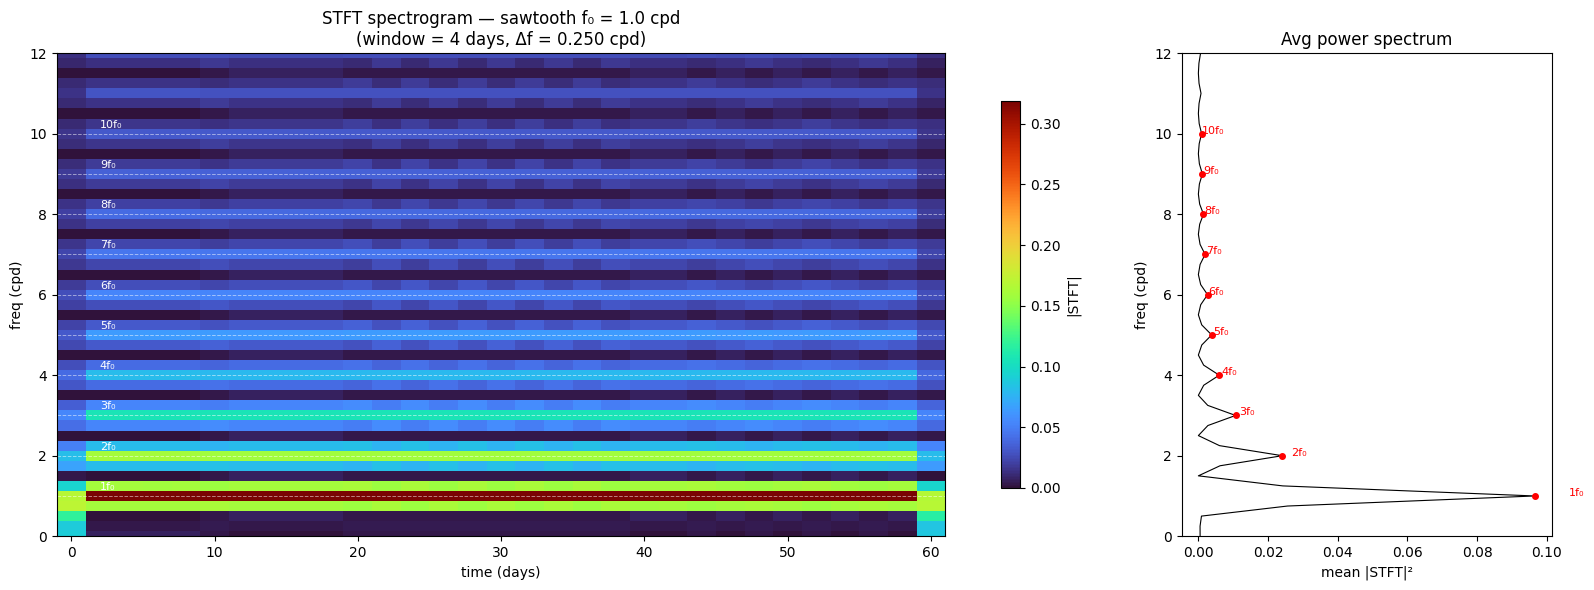


Harmonic   cpd      |STFT|²      Relative   Theory 1/n² 
----------------------------------------------------
1f₀        1.0      9.6585e-02   1.0000     1.0000      
2f₀        2.0      2.4098e-02   0.2495     0.2500      
3f₀        3.0      1.0698e-02   0.1108     0.1111      
4f₀        4.0      6.0092e-03   0.0622     0.0625      
5f₀        5.0      3.8393e-03   0.0397     0.0400      
6f₀        6.0      2.6606e-03   0.0275     0.0278      
7f₀        7.0      1.9499e-03   0.0202     0.0204      
8f₀        8.0      1.4887e-03   0.0154     0.0156      
9f₀        9.0      1.1725e-03   0.0121     0.0123      
10f₀        10.0     9.4630e-04   0.0098     0.0100      


In [65]:
# ---- STFT spectrogram of sawtooth — linear frequency axis ----
from scipy.signal import stft as _stft

# ---- STFT parameters ----
# nperseg controls freq resolution: longer window = finer freq bins
# For 10-min sampling at 1 cpd fundamental, 1 day = 144 samples
nperseg = 144 * 4    # 4-day window → freq resolution ~0.25 cpd
noverlap = nperseg // 2

f_stft, t_stft, Zxx = _stft(x_saw, fs=fs_saw, nperseg=nperseg,
                              noverlap=noverlap, window='hann')

# Convert to cpd and days
f_stft_cpd = f_stft * 86400.0
t_stft_days = t_stft / 86400.0

print(f"STFT: {Zxx.shape[0]} freq bins, {Zxx.shape[1]} time frames")
print(f"Freq resolution: {(f_stft_cpd[1] - f_stft_cpd[0]):.4f} cpd")
print(f"Window: {nperseg} samples = {nperseg * dt_saw / 86400:.1f} days")

# ---- Plot: STFT spectrogram + power spectrum ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6), width_ratios=[3, 1])

# Spectrogram
pcm = axes[0].pcolormesh(t_stft_days, f_stft_cpd, np.abs(Zxx),
                          cmap='turbo', shading='auto', rasterized=True)
axes[0].set_ylabel('freq (cpd)')
axes[0].set_xlabel('time (days)')
axes[0].set_ylim(0, 12)
axes[0].set_title(f'STFT spectrogram — sawtooth f₀ = {f0_cpd} cpd\n'
                  f'(window = {nperseg * dt_saw / 86400:.0f} days, '
                  f'Δf = {(f_stft_cpd[1] - f_stft_cpd[0]):.3f} cpd)')
fig.colorbar(pcm, ax=axes[0], label='|STFT|', shrink=0.8)

# annotate harmonics
for k in range(1, 11):
    fk = k * f0_cpd
    if fk <= 12:
        axes[0].axhline(fk, color='white', linewidth=0.7, linestyle='--', alpha=0.5)
        axes[0].text(t_stft_days[1], fk + 0.15, f'{k}f₀', color='white', fontsize=8)

# Time-averaged power spectrum (right panel)
power_avg = np.mean(np.abs(Zxx)**2, axis=1)
axes[1].plot(power_avg, f_stft_cpd, 'k-', linewidth=0.8)
axes[1].set_ylim(0, 12)
axes[1].set_xlabel('mean |STFT|²')
axes[1].set_ylabel('freq (cpd)')
axes[1].set_title('Avg power spectrum')

# mark harmonic peaks
for k in range(1, 11):
    fk = k * f0_cpd
    if fk <= 12:
        row = np.argmin(np.abs(f_stft_cpd - fk))
        axes[1].plot(power_avg[row], f_stft_cpd[row], 'ro', ms=4)
        axes[1].text(power_avg[row] * 1.1, f_stft_cpd[row],
                     f'{k}f₀', fontsize=8, color='red')

fig.tight_layout()
plt.show()

# ---- Print harmonic amplitudes ----
print(f"\n{'Harmonic':<10} {'cpd':<8} {'|STFT|²':<12} {'Relative':<10} {'Theory 1/n²':<12}")
print("-" * 52)
p_fund = None
for k in range(1, 11):
    fk = k * f0_cpd
    row = np.argmin(np.abs(f_stft_cpd - fk))
    p = power_avg[row]
    if k == 1:
        p_fund = p
    rel = p / p_fund if p_fund else 0
    theory = 1.0 / k**2
    print(f"{k}f₀        {fk:<8.1f} {p:<12.4e} {rel:<10.4f} {theory:<12.4f}")

## STFT of XMR1 creepmeter data — linear frequency axis

1-year window STFT for harmonic detection. Linear freq axis so harmonics
of any fundamental appear as **evenly spaced** horizontal bands.

FFTW STFT: 210241 freq bins × 8 windows
Freq resolution (true): 0.002740 cpd
Freq bin spacing (interpolated): 0.000342 cpd
Window: 365 days, nfft: 420480 (8× zero-pad)
Overlap: 75%


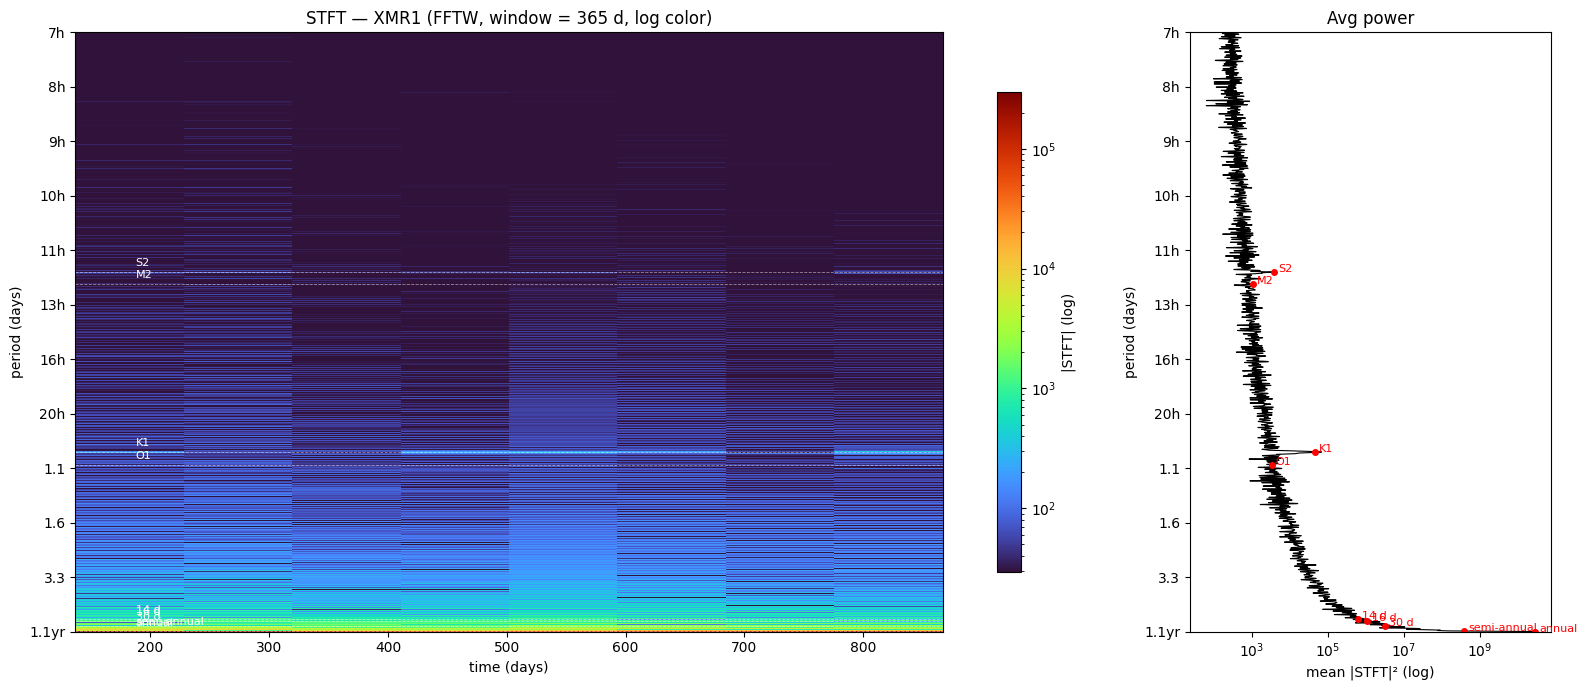

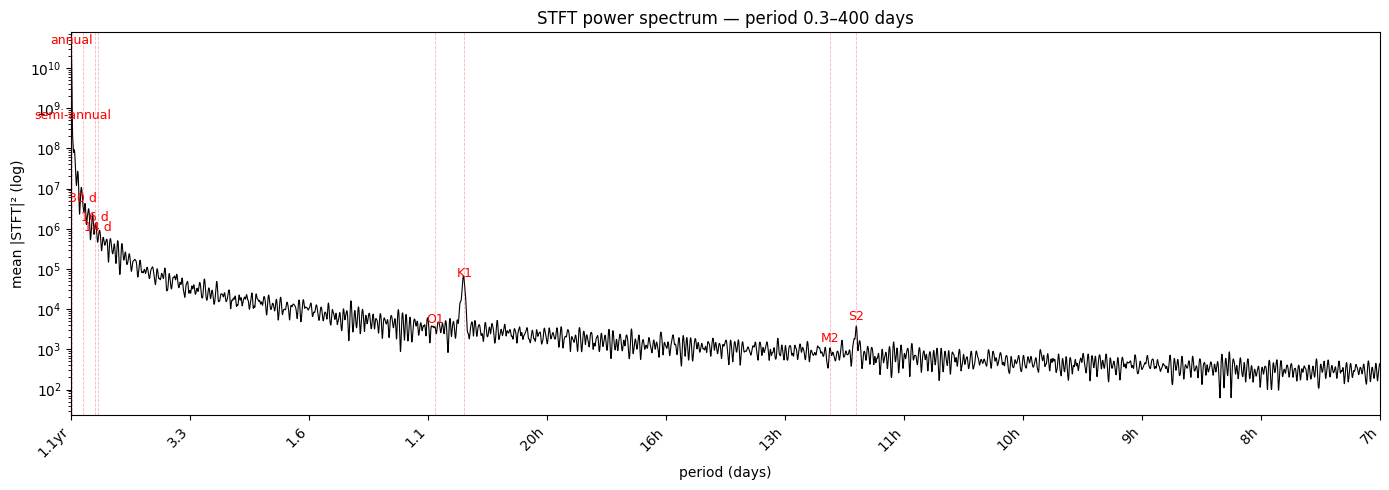


Top spectral peaks (0.3–400 day range):
Rank   Period           cpd          Power       
----------------------------------------------
1      100.69 days      0.0099       9.2786e+07  
2      53.09 days       0.0188       2.7020e+07  
3      35.61 days       0.0281       1.0653e+07  
4      26.55 days       0.0377       4.2710e+06  
5      21.47 days       0.0466       3.1426e+06  
6      17.59 days       0.0568       2.3588e+06  
7      15.61 days       0.0640       1.3783e+06  
8      13.46 days       0.0743       9.1339e+05  
9      11.92 days       0.0839       6.1144e+05  
10     9.80 days        0.1021       5.6901e+05  
11     10.77 days       0.0928       5.5098e+05  
12     8.27 days        0.1209       5.0522e+05  
13     7.62 days        0.1312       4.2776e+05  
14     8.93 days        0.1120       4.1869e+05  
15     7.14 days        0.1401       2.6428e+05  
16     6.65 days        0.1503       2.3880e+05  
17     6.10 days        0.1640       1.7322e+05  
18     5.63 

In [2]:
# ---- STFT spectrogram of XMR1 — FFTW backend, 1-year window ----
import pyfftw
from matplotlib.colors import LogNorm
from scipy.signal import find_peaks

# ---- STFT parameters ----
nperseg = 144 * 365   # 1-year window (samples)
noverlap = nperseg * 3 // 4  # 75% overlap
zeropad_factor = 8
nfft = nperseg * zeropad_factor

# ---- Build STFT via FFTW ----
step = nperseg - noverlap
n_frames = 1 + (len(x) - nperseg) // step

# Hann window
window = np.hanning(nperseg)

# FFTW plan (real → complex, MEASURE for best algorithm)
fftw_in = pyfftw.empty_aligned(nfft, dtype='float64')
fftw_out = pyfftw.empty_aligned(nfft // 2 + 1, dtype='complex128')
fftw_plan = pyfftw.FFTW(fftw_in, fftw_out, direction='FFTW_FORWARD',
                         flags=['FFTW_MEASURE'], threads=1)

n_freq = nfft // 2 + 1
Zxx = np.empty((n_freq, n_frames), dtype='complex128')
t_stft = np.empty(n_frames)

for i in range(n_frames):
    start = i * step
    segment = x[start:start + nperseg] * window
    fftw_in[:nperseg] = segment
    fftw_in[nperseg:] = 0.0  # zero-pad
    fftw_plan()
    Zxx[:, i] = fftw_out.copy()
    t_stft[i] = (start + nperseg / 2) * dt  # center of window in seconds

f_stft = np.arange(n_freq) * (fs / nfft)
f_stft_cpd = f_stft * 86400.0
t_stft_days = t_stft / 86400.0
df_cpd = f_stft_cpd[1] - f_stft_cpd[0]

# Per-window power (n_freq × n_frames) and time-averaged
power_per_window = np.abs(Zxx)**2
power_avg = np.mean(power_per_window, axis=1)

print(f"FFTW STFT: {n_freq} freq bins × {n_frames} windows")
print(f"Freq resolution (true): {1/(nperseg * dt / 86400):.6f} cpd")
print(f"Freq bin spacing (interpolated): {df_cpd:.6f} cpd")
print(f"Window: {nperseg * dt / 86400:.0f} days, nfft: {nfft} ({zeropad_factor}× zero-pad)")
print(f"Overlap: {noverlap/nperseg*100:.0f}%")

# ============================================================
# Change these to adjust the display range — all plots follow
# ============================================================
period_lo = 0.3     # shortest period (days)
period_hi = 400     # longest period (days)

# Convert period range → freq range
f_lo_disp = 1.0 / period_hi  # cpd
f_hi_disp = 1.0 / period_lo  # cpd
fmask = (f_stft_cpd >= f_lo_disp) & (f_stft_cpd <= f_hi_disp)

# reference periods for annotation
tidal_periods = {'S2': 0.500, 'M2': 0.517, 'K1': 0.997, 'O1': 1.076}
other_periods = {'14 d': 14, '16 d': 16, '30 d': 30,
                 'semi-annual': 365.25/2, 'annual': 365.25}
all_periods = {**tidal_periods, **other_periods}

# Helper: build period tick labels for a linear freq axis
def period_ticks_for_freq_range(f_lo, f_hi, n=12):
    tick_freqs = np.linspace(f_lo, f_hi, n)
    tick_periods = 1.0 / tick_freqs
    labels = []
    for p in tick_periods:
        if p >= 365:
            labels.append(f'{p/365:.1f}yr')
        elif p >= 1:
            labels.append(f'{p:.1f}')
        else:
            labels.append(f'{p*24:.0f}h')
    return tick_freqs, labels

tick_freqs, tick_labels = period_ticks_for_freq_range(f_lo_disp, f_hi_disp)

# ---- Plot 1: Spectrogram — LOG color scale ----
fig, axes = plt.subplots(1, 2, figsize=(16, 7), width_ratios=[3, 1])

f_masked = f_stft_cpd[fmask]
Z_masked = np.abs(Zxx[fmask, :])

z_max = Z_masked.max()
z_floor = z_max * 1e-4
Z_plot = np.clip(Z_masked, z_floor, None)

T_mesh, F_mesh = np.meshgrid(t_stft_days, f_masked)
pcm = axes[0].pcolormesh(T_mesh, F_mesh, Z_plot,
                          cmap='turbo', shading='auto', rasterized=True,
                          norm=LogNorm(vmin=z_floor, vmax=z_max))
axes[0].set_xlabel('time (days)')
axes[0].set_ylabel('period (days)')
axes[0].set_title(f'STFT — XMR1 (FFTW, window = {nperseg * dt / 86400:.0f} d, log color)')
axes[0].set_yticks(tick_freqs)
axes[0].set_yticklabels(tick_labels)
fig.colorbar(pcm, ax=axes[0], label='|STFT| (log)', shrink=0.8)

for name, p in all_periods.items():
    if period_lo <= p <= period_hi:
        axes[0].axhline(1.0/p, color='white', linewidth=0.6, linestyle='--', alpha=0.5)
        axes[0].text(t_stft_days[0] + 5, 1.0/p + (f_hi_disp - f_lo_disp)*0.01,
                     name, color='white', fontsize=8)

pow_masked = power_avg[fmask]
axes[1].semilogx(pow_masked, f_masked, 'k-', linewidth=0.8)
axes[1].set_ylim(f_lo_disp, f_hi_disp)
axes[1].set_yticks(tick_freqs)
axes[1].set_yticklabels(tick_labels)
axes[1].set_xlabel('mean |STFT|² (log)')
axes[1].set_ylabel('period (days)')
axes[1].set_title('Avg power')

for name, p in all_periods.items():
    if period_lo <= p <= period_hi:
        row = np.argmin(np.abs(f_masked - 1.0/p))
        axes[1].plot(pow_masked[row], f_masked[row], 'ro', ms=4)
        axes[1].text(pow_masked[row] * 1.3, f_masked[row], name,
                     fontsize=8, color='red')

fig.tight_layout()
plt.show()

# ---- Plot 2: Power spectrum — log y ----
fig, ax = plt.subplots(figsize=(14, 5))
ax.semilogy(f_masked, pow_masked, 'k-', linewidth=0.8)
ax.set_xlim(f_lo_disp, f_hi_disp)
ax.set_xticks(tick_freqs)
ax.set_xticklabels(tick_labels, rotation=45, ha='right')
ax.set_xlabel('period (days)')
ax.set_ylabel('mean |STFT|² (log)')
ax.set_title(f'STFT power spectrum — period {period_lo}–{period_hi} days')

for name, p in all_periods.items():
    if period_lo <= p <= period_hi:
        f_ann = 1.0 / p
        row = np.argmin(np.abs(f_masked - f_ann))
        ax.axvline(f_ann, color='red', linewidth=0.6, linestyle='--', alpha=0.3)
        ax.text(f_ann, pow_masked[row] * 1.2, name, fontsize=9, color='red',
                ha='center', va='bottom')

fig.tight_layout()
plt.show()

# ---- Print top peaks ----
fmask_idx = np.where(fmask)[0]
pow_in_range = power_avg[fmask_idx]
peaks_local, _ = find_peaks(pow_in_range, height=np.median(pow_in_range) * 3, distance=3)
peaks_global = fmask_idx[peaks_local]
peaks_sorted = peaks_global[np.argsort(power_avg[peaks_global])[::-1]]

print(f"\nTop spectral peaks ({period_lo}–{period_hi} day range):")
print(f"{'Rank':<6} {'Period':<16} {'cpd':<12} {'Power':<12}")
print("-" * 46)
for i, pk in enumerate(peaks_sorted[:20]):
    f = f_stft_cpd[pk]
    p = 1.0 / f if f > 0 else np.inf
    if p >= 365:
        p_str = f"{p/365:.2f} yr"
    elif p >= 1:
        p_str = f"{p:.2f} days"
    else:
        p_str = f"{p*24:.2f} hr"
    print(f"{i+1:<6} {p_str:<16} {f:<12.4f} {power_avg[pk]:<12.4e}")


## Harmonic identification — HPS & spectral autocorrelation

Two methods to find **families of harmonics** in the XMR1 power spectrum:

1. **Harmonic Product Spectrum (HPS)** — downsample the power spectrum by integer factors (2×, 3×, 4×, 5×) and multiply. Harmonics of a fundamental collapse onto a single peak.
2. **Spectral autocorrelation** — autocorrelate the log-power spectrum. Evenly-spaced harmonic peaks produce a periodic pattern whose lag reveals the fundamental spacing.

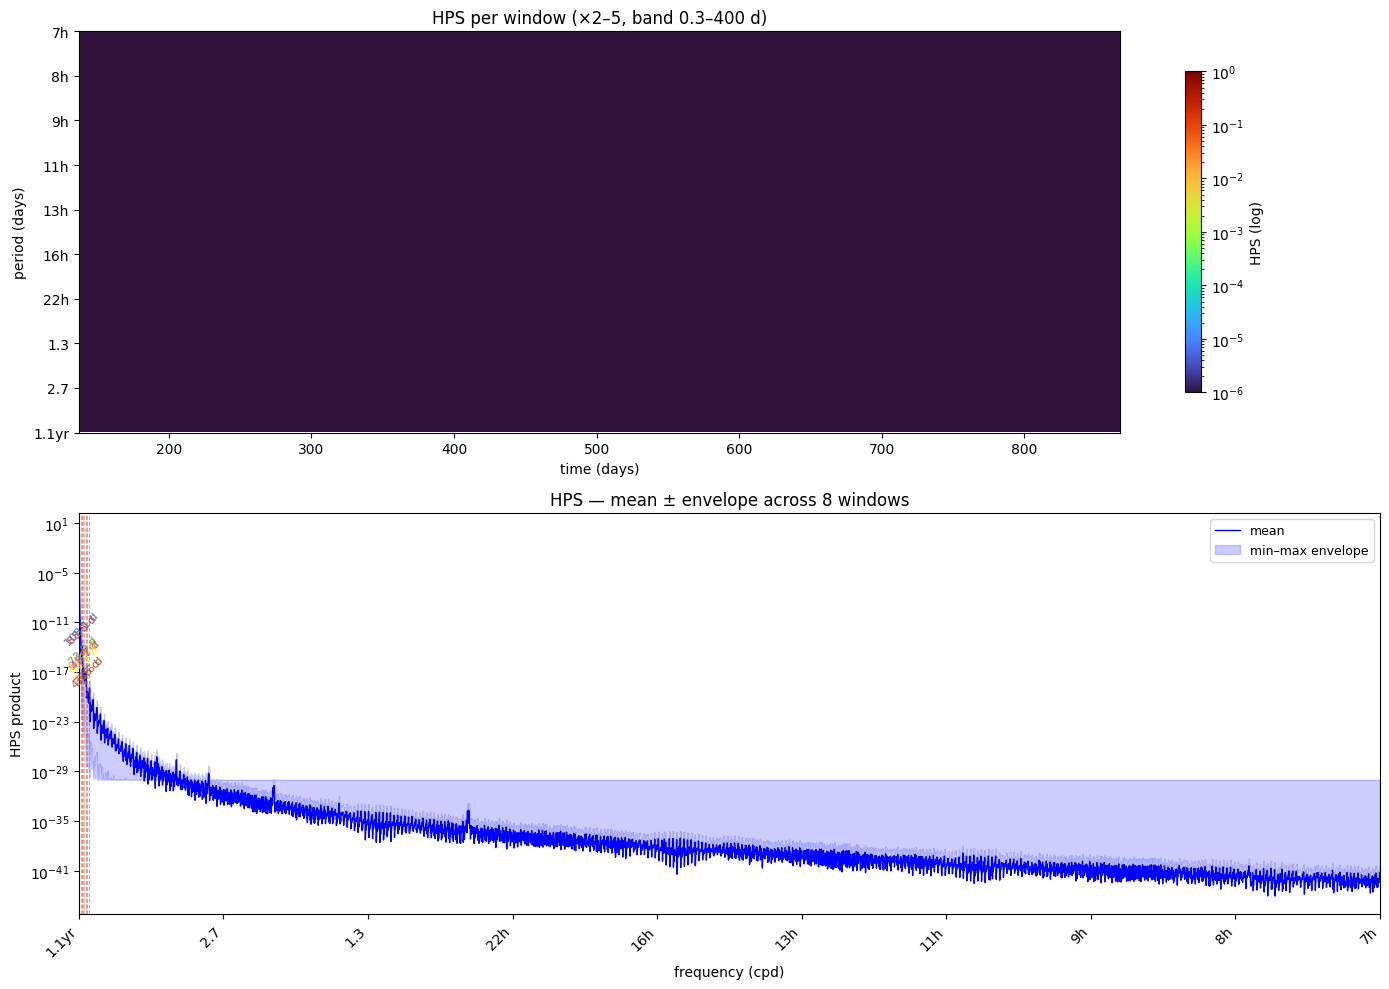


Top HPS fundamentals (mean over 8 windows):
Rank   Fundamental      cpd        HPS mean    
--------------------------------------------
1      88.5 days        0.0113     1.2665e-14  
2      108.1 days       0.0092     6.3837e-15  
3      73.0 days        0.0137     3.3056e-17  
4      48.7 days        0.0205     1.1810e-17  
5      64.9 days        0.0154     8.2769e-18  
6      54.1 days        0.0185     2.1907e-18  
7      33.6 days        0.0298     1.2097e-19  
8      43.6 days        0.0229     4.7614e-20  
9      40.6 days        0.0247     4.2528e-20  
10     35.6 days        0.0281     1.6551e-20  


In [3]:
# ---- Harmonic Product Spectrum (HPS) — per-window, band-limited ----
# Run HPS on each STFT window independently to see when harmonic
# families appear / disappear over time.

from scipy.signal import find_peaks as _find_peaks

max_downsample = 5

# Band-limit
f_lo_hps = f_lo_disp
f_hi_hps = f_hi_disp * max_downsample  # room for harmonics
band_mask_hps = (f_stft_cpd[1:] >= f_lo_hps) & (f_stft_cpd[1:] <= f_hi_hps)
f_band = f_stft_cpd[1:][band_mask_hps]
N_band = len(f_band)
hps_len = N_band // max_downsample
f_hps = f_band[:hps_len]

# Compute HPS for each window
hps_all = np.zeros((hps_len, n_frames))
for wi in range(n_frames):
    pow_win = power_per_window[1:, wi][band_mask_hps]
    pn = pow_win / (pow_win.max() + 1e-30)
    h = pn.copy()
    for k in range(2, max_downsample + 1):
        dec = pn[::k]
        h[:len(dec)] *= dec
    hps_all[:, wi] = h[:hps_len]

# Also compute time-averaged HPS for reference
hps_avg = np.mean(hps_all, axis=1)

# ---- Plot 1: HPS spectrogram (time × freq) ----
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Restrict display to the fundamental range (not the extended harmonic range)
disp_mask = (f_hps >= f_lo_disp) & (f_hps <= f_hi_disp)
f_hps_disp = f_hps[disp_mask]
hps_disp = hps_all[disp_mask, :]

T_hps, F_hps = np.meshgrid(t_stft_days, f_hps_disp)
h_max = hps_disp.max()
h_floor = max(h_max * 1e-6, 1e-30)
pcm = axes[0].pcolormesh(T_hps, F_hps, np.clip(hps_disp, h_floor, None),
                          cmap='turbo', shading='auto', rasterized=True,
                          norm=LogNorm(vmin=h_floor, vmax=h_max))
axes[0].set_xlabel('time (days)')
axes[0].set_ylabel('period (days)')
axes[0].set_title(f'HPS per window (×2–{max_downsample}, band {period_lo}–{period_hi} d)')

# Period tick labels
tick_f_hps, tick_l_hps = period_ticks_for_freq_range(f_lo_disp, f_hi_disp, n=10)
axes[0].set_yticks(tick_f_hps)
axes[0].set_yticklabels(tick_l_hps)
fig.colorbar(pcm, ax=axes[0], label='HPS (log)', shrink=0.8)

# ---- Plot 2: time-averaged HPS + per-window envelope ----
hps_avg_disp = hps_avg[disp_mask]
hps_max_env = np.max(hps_all[disp_mask, :], axis=1)
hps_min_env = np.min(hps_all[disp_mask, :], axis=1)

axes[1].semilogy(f_hps_disp, hps_avg_disp, 'b-', linewidth=1.0, label='mean')
axes[1].fill_between(f_hps_disp, hps_min_env + 1e-30, hps_max_env,
                      alpha=0.2, color='blue', label='min–max envelope')
axes[1].set_xlabel('frequency (cpd)')
axes[1].set_ylabel('HPS product')
axes[1].set_title(f'HPS — mean ± envelope across {n_frames} windows')
axes[1].set_xlim(f_lo_disp, f_hi_disp)
axes[1].set_xticks(tick_f_hps)
axes[1].set_xticklabels(tick_l_hps, rotation=45, ha='right')
axes[1].legend(fontsize=9)

# Annotate top peaks of the average
peaks_hps, _ = _find_peaks(hps_avg_disp, height=np.median(hps_avg_disp) * 5, distance=5)
peaks_hps_sorted = peaks_hps[np.argsort(hps_avg_disp[peaks_hps])[::-1]]
colors_hps = plt.cm.Set1(np.linspace(0, 1, min(10, len(peaks_hps_sorted))))
for i, pk in enumerate(peaks_hps_sorted[:8]):
    f_pk = f_hps_disp[pk]
    p_pk = 1.0 / f_pk
    if p_pk >= 365:
        p_str = f"{p_pk/365:.2f} yr"
    elif p_pk >= 1:
        p_str = f"{p_pk:.1f} d"
    else:
        p_str = f"{p_pk*24:.1f} h"
    axes[1].axvline(f_pk, color=colors_hps[i], linewidth=0.8, linestyle='--', alpha=0.5)
    axes[1].text(f_pk, hps_avg_disp[pk] * 1.5, p_str, fontsize=8,
                 color=colors_hps[i], ha='center', va='bottom', rotation=45)

fig.tight_layout()
plt.show()

# Print top HPS fundamentals
print(f"\nTop HPS fundamentals (mean over {n_frames} windows):")
print(f"{'Rank':<6} {'Fundamental':<16} {'cpd':<10} {'HPS mean':<12}")
print("-" * 44)
for i, pk in enumerate(peaks_hps_sorted[:10]):
    f_pk = f_hps_disp[pk]
    p_pk = 1.0 / f_pk
    if p_pk >= 365:
        p_str = f"{p_pk/365:.2f} yr"
    elif p_pk >= 1:
        p_str = f"{p_pk:.1f} days"
    else:
        p_str = f"{p_pk*24:.1f} hr"
    print(f"{i+1:<6} {p_str:<16} {f_pk:<10.4f} {hps_avg_disp[pk]:<12.4e}")


FFTW per-window ACF: 9726 bins × 8 windows, band 0.3–400 d, padded to 32768


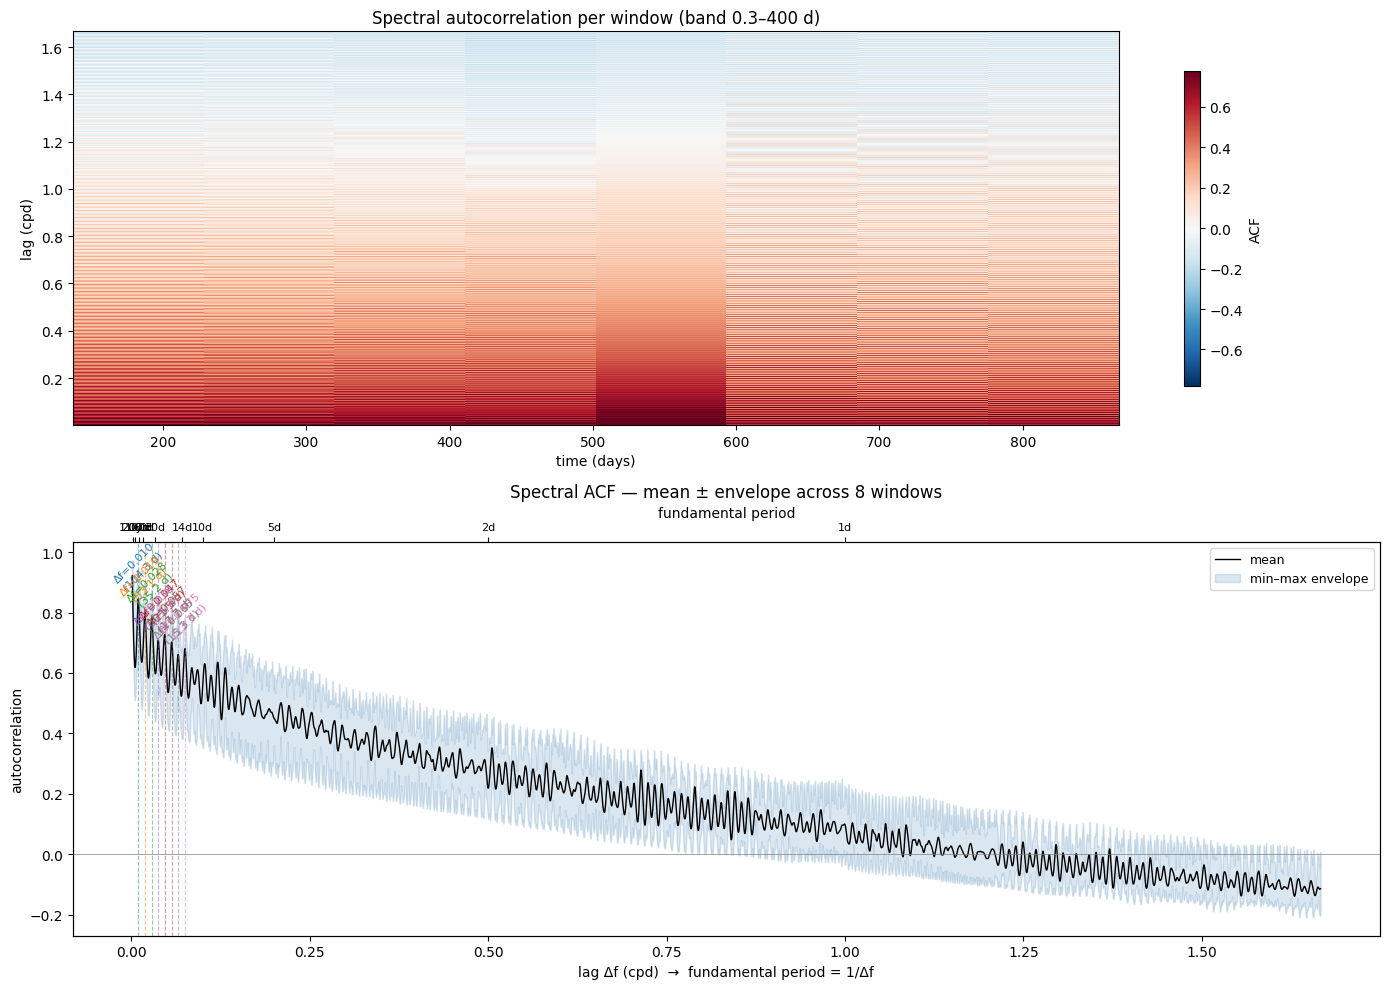


Detected harmonic spacings (mean ACF peaks):
Rank   Δf (cpd)     Fund. period     ACF height  
----------------------------------------------
1      0.0096       104.3 days       0.8450      
2      0.0188       53.1 days        0.8017      
3      0.0284       35.2 days        0.7827      
4      0.0466       21.5 days        0.7275      
5      0.0377       26.5 days        0.7081      
6      0.0565       17.7 days        0.7022      
7      0.0750       13.3 days        0.6805      
8      0.0654       15.3 days        0.6610      
9      0.1209       8.3 days         0.6357      
10     0.1027       9.7 days         0.6309      


In [4]:
# ---- Spectral autocorrelation (FFTW) — per-window, band-limited ----
# Run spectral autocorrelation on each STFT window independently.

import pyfftw
from scipy.signal import find_peaks as _find_peaks

# Band-limit
band_mask_acf = (f_stft_cpd[1:] >= f_lo_disp) & (f_stft_cpd[1:] <= f_hi_disp)
f_band_acf = f_stft_cpd[1:][band_mask_acf]
n_acf = int(band_mask_acf.sum())

# FFTW plan for autocorrelation (reusable across windows)
n_padded = int(2 ** np.ceil(np.log2(2 * n_acf)))
acf_in = pyfftw.empty_aligned(n_padded, dtype='float64')
acf_fwd_out = pyfftw.empty_aligned(n_padded // 2 + 1, dtype='complex128')
acf_back = pyfftw.empty_aligned(n_padded, dtype='float64')

fft_fwd = pyfftw.FFTW(acf_in, acf_fwd_out, direction='FFTW_FORWARD',
                       flags=['FFTW_MEASURE'], threads=1)
fft_inv = pyfftw.FFTW(acf_fwd_out, acf_back, direction='FFTW_BACKWARD',
                       flags=['FFTW_MEASURE'], threads=1)

# Compute ACF for each window
acf_all = np.zeros((n_acf, n_frames))
for wi in range(n_frames):
    pow_win = power_per_window[1:, wi][band_mask_acf]
    lp = np.log10(pow_win + 1e-30)
    lp -= lp.mean()
    acf_in[:n_acf] = lp
    acf_in[n_acf:] = 0.0
    fft_fwd()
    acf_fwd_out[:] = np.abs(acf_fwd_out) ** 2
    fft_inv()
    acf_win = acf_back[:n_acf].copy()
    acf_win /= (acf_win[0] + 1e-30)
    acf_all[:, wi] = acf_win

acf_avg = np.mean(acf_all, axis=1)

df_bin = f_band_acf[1] - f_band_acf[0]
lag_cpd = np.arange(n_acf) * df_bin

print(f"FFTW per-window ACF: {n_acf} bins × {n_frames} windows, "
      f"band {period_lo}–{period_hi} d, padded to {n_padded}")

# Restrict to meaningful lags
max_lag_cpd = min(f_hi_disp / 2, lag_cpd[-1])
lag_mask = (lag_cpd > 0.001) & (lag_cpd <= max_lag_cpd)
lag_cpd_m = lag_cpd[lag_mask]
acf_avg_m = acf_avg[lag_mask]

# ---- Plot 1: ACF spectrogram (time × lag) ----
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

acf_disp = acf_all[lag_mask, :]
T_acf, L_acf = np.meshgrid(t_stft_days, lag_cpd_m)
vabs = max(abs(acf_disp.min()), abs(acf_disp.max())) * 0.8
pcm = axes[0].pcolormesh(T_acf, L_acf, acf_disp,
                          cmap='RdBu_r', shading='auto', rasterized=True,
                          vmin=-vabs, vmax=vabs)
axes[0].set_xlabel('time (days)')
axes[0].set_ylabel('lag (cpd)')
axes[0].set_title(f'Spectral autocorrelation per window (band {period_lo}–{period_hi} d)')
fig.colorbar(pcm, ax=axes[0], label='ACF', shrink=0.8)

# ---- Plot 2: time-averaged ACF with envelope ----
acf_max_env = np.max(acf_disp, axis=1)
acf_min_env = np.min(acf_disp, axis=1)

axes[1].plot(lag_cpd_m, acf_avg_m, 'k-', linewidth=1.0, label='mean')
axes[1].fill_between(lag_cpd_m, acf_min_env, acf_max_env,
                      alpha=0.2, color='steelblue', label='min–max envelope')
axes[1].axhline(0, color='gray', linewidth=0.5)
axes[1].set_xlabel('lag Δf (cpd)  →  fundamental period = 1/Δf')
axes[1].set_ylabel('autocorrelation')
axes[1].set_title(f'Spectral ACF — mean ± envelope across {n_frames} windows')
axes[1].legend(fontsize=9)

# Add a twin x-axis showing fundamental period
ax2 = axes[1].twiny()
ax2.set_xlim(axes[1].get_xlim())
period_ticks_vals = [0.5, 1, 2, 5, 10, 14, 30, 60, 100, 200, 365]
period_ticks_cpd = [1.0/p for p in period_ticks_vals if
                    lag_cpd_m[0] <= 1.0/p <= lag_cpd_m[-1]]
period_ticks_lab = [f"{p:.0f}d" if p < 365 else f"{p/365:.1f}yr"
                    for p in period_ticks_vals if
                    lag_cpd_m[0] <= 1.0/p <= lag_cpd_m[-1]]
ax2.set_xticks(period_ticks_cpd)
ax2.set_xticklabels(period_ticks_lab, fontsize=8)
ax2.set_xlabel('fundamental period')

# Annotate top peaks
acf_peaks, _ = _find_peaks(acf_avg_m, height=0.05, distance=3, prominence=0.02)
acf_peaks_sorted = acf_peaks[np.argsort(acf_avg_m[acf_peaks])[::-1]]
colors_acf = plt.cm.tab10(np.linspace(0, 1, 10))
for i, pk in enumerate(acf_peaks_sorted[:8]):
    lag_val = lag_cpd_m[pk]
    period_fund = 1.0 / lag_val
    if period_fund >= 365:
        p_str = f"{period_fund/365:.2f} yr"
    elif period_fund >= 1:
        p_str = f"{period_fund:.1f} d"
    else:
        p_str = f"{period_fund*24:.1f} h"
    axes[1].axvline(lag_val, color=colors_acf[i], linewidth=0.8,
                     linestyle='--', alpha=0.5)
    axes[1].text(lag_val, acf_avg_m[pk] + 0.02, f"Δf={lag_val:.3f}\n({p_str})",
                 fontsize=8, color=colors_acf[i], ha='center', va='bottom', rotation=45)

fig.tight_layout()
plt.show()

# Print detected harmonic spacings
print("\nDetected harmonic spacings (mean ACF peaks):")
print(f"{'Rank':<6} {'Δf (cpd)':<12} {'Fund. period':<16} {'ACF height':<12}")
print("-" * 46)
for i, pk in enumerate(acf_peaks_sorted[:10]):
    lag_val = lag_cpd_m[pk]
    period_fund = 1.0 / lag_val
    if period_fund >= 365:
        p_str = f"{period_fund/365:.2f} yr"
    elif period_fund >= 1:
        p_str = f"{period_fund:.1f} days"
    else:
        p_str = f"{period_fund*24:.1f} hr"
    print(f"{i+1:<6} {lag_val:<12.4f} {p_str:<16} {acf_avg_m[pk]:<12.4f}")


## Wavelet leaders — oscillating singularity detection

**Wavelet leaders** (Jaffard, Wendt & Abry 2007) use an orthogonal DWT (db4) to build a multifractal formalism that can distinguish **oscillating singularities** from regular ones.

The idea: compute the **structure functions** S(q, j) from DWT detail coefficients and the **leader functions** L(q, j) from wavelet leaders (local suprema). If the scaling exponents ζ(q) from both agree → regular singularities. If they **disagree** → oscillating singularities are present, and the gap measures the oscillation exponent β.

| Quantity | Definition |
|----------|-----------|
| Detail coeff d(j,k) | DWT at scale j, position k |
| Leader L(j,k) | sup of \|d(j',k')\| over j'≤j in a neighborhood of k |
| Structure fn S(q,j) | mean(\|d\|^q) — should scale as 2^(jζ(q)) |
| Leader fn Λ(q,j) | mean(L^q) — should scale as 2^(jζ_L(q)) |
| Oscillation test | ζ(q) ≠ ζ_L(q) → oscillating singularities |

Signal: 154031 samples, dt = 10.0 min, span = 1069.7 days (2.9 yr)
DWT: wavelet=db4, max level=14

Level    N coeffs     Scale (days)     Period range             Band
--------------------------------------------------------------------------------
14       16           113.778          113.8 d – 227.6 d        ★ seasonal / annual
13       25           56.889           56.9 d – 113.8 d         ★ monthly / seasonal
12       44           28.444           28.4 d – 56.9 d          ★ monthly / seasonal
11       82           14.222           14.2 d – 28.4 d          ★ monthly / seasonal
10       157          7.111            7.1 d – 14.2 d           ★ multi-day / fortnightly
9        307          3.556            3.6 d – 7.1 d            ★ multi-day / fortnightly
8        608          1.778            1.8 d – 3.6 d            ★ multi-day / fortnightly
7        1210         0.889            21.3 hr – 1.8 d          ★ TIDAL (S2/M2/K1/O1)
6        2413         0.444            10.7 hr – 21.3 hr

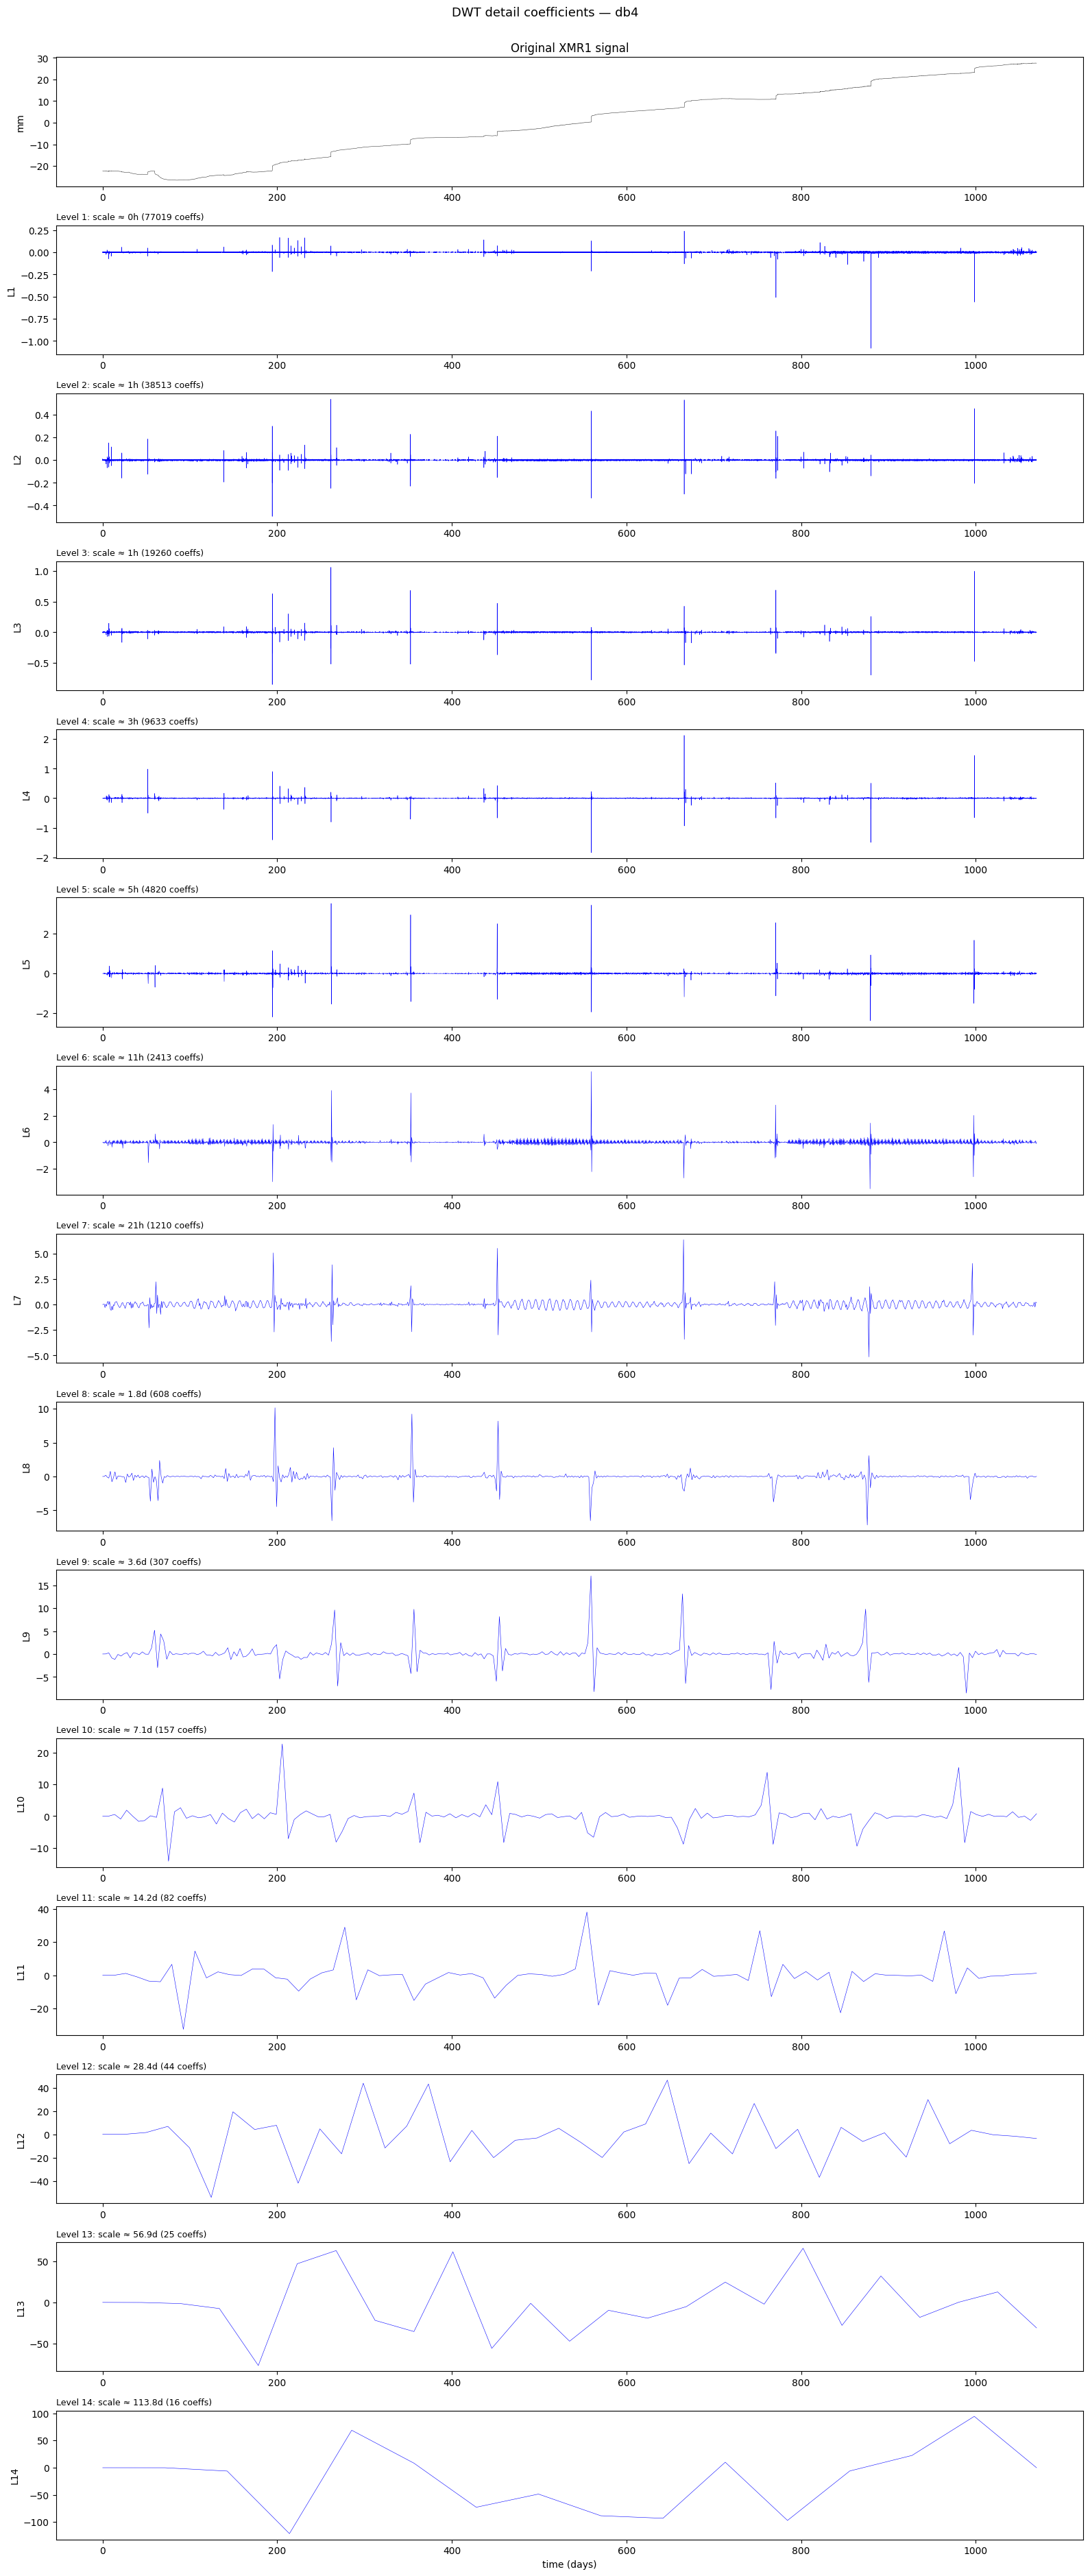

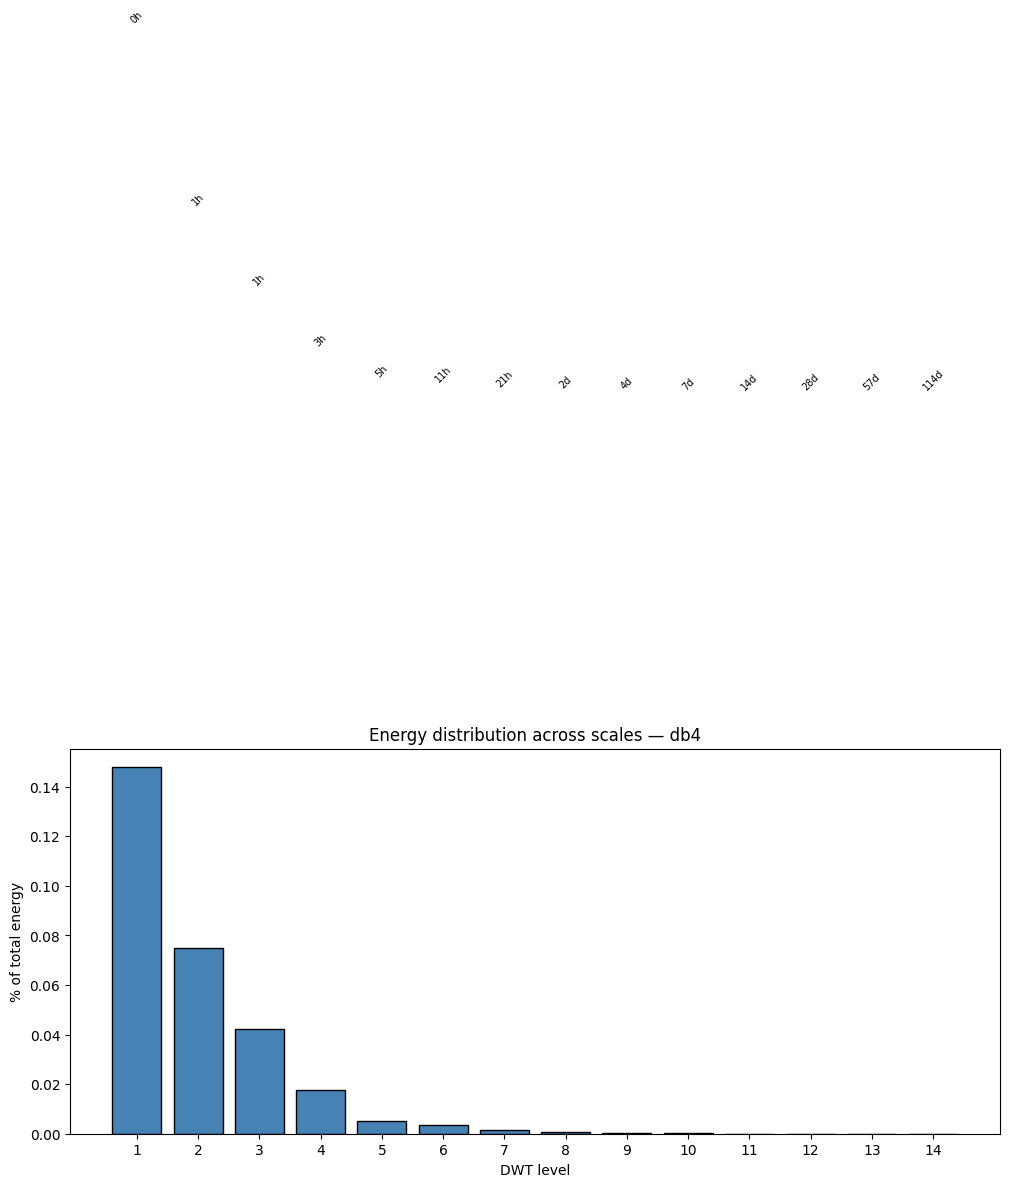


Approximation energy: 236.7% (trend > 114 days)
Detail energy: 0.3%


In [2]:
# ---- DWT of the full XMR1 signal — explore all dyadic scales ----
import pywt

wavelet_dwt = 'db4'
max_level = pywt.dwt_max_level(len(x), wavelet_dwt)

coeffs = pywt.wavedec(x, wavelet_dwt, level=max_level)
n_levels = len(coeffs) - 1
detail_coeffs = coeffs[1:]  # index 0 = coarsest detail

# ---- Print scale table ----
dt_days = dt / 86400.0
print(f"Signal: {len(x)} samples, dt = {dt_days*24*60:.1f} min, "
      f"span = {len(x)*dt_days:.1f} days ({len(x)*dt_days/365.25:.1f} yr)")
print(f"DWT: wavelet={wavelet_dwt}, max level={max_level}\n")

print(f"{'Level':<8} {'N coeffs':<12} {'Scale (days)':<16} {'Period range':<24} {'Band'}")
print("-" * 80)
for j in range(n_levels):
    # level j in pywt: detail_coeffs[0] = coarsest, detail_coeffs[-1] = finest
    # pywt convention: level 1 = finest, level max = coarsest
    # detail_coeffs is ordered coarsest→finest, so index 0 = level max_level
    pywt_level = n_levels - j  # pywt level number (1=finest)
    n_c = len(detail_coeffs[j])
    scale_samples = 2 ** pywt_level
    scale_days = scale_samples * dt_days
    period_lo_d = scale_days      # Nyquist-like lower bound
    period_hi_d = 2 * scale_days  # upper bound of the octave
    
    # Friendly label
    def fmt_period(d):
        if d >= 365.25:
            return f"{d/365.25:.1f} yr"
        elif d >= 1:
            return f"{d:.1f} d"
        elif d >= 1/24:
            return f"{d*24:.1f} hr"
        else:
            return f"{d*24*60:.0f} min"
    
    band = f"{fmt_period(period_lo_d)} – {fmt_period(period_hi_d)}"
    
    # Classify
    if period_hi_d < 0.5:
        tag = "sub-tidal noise"
    elif period_lo_d <= 1.1 and period_hi_d >= 0.4:
        tag = "★ TIDAL (S2/M2/K1/O1)"
    elif period_lo_d <= 14 and period_hi_d >= 2:
        tag = "★ multi-day / fortnightly"
    elif period_lo_d <= 60 and period_hi_d >= 14:
        tag = "★ monthly / seasonal"
    elif period_lo_d <= 365 and period_hi_d >= 60:
        tag = "★ seasonal / annual"
    elif period_lo_d > 365:
        tag = "★ multi-year trend"
    else:
        tag = ""
    
    print(f"{pywt_level:<8} {n_c:<12} {scale_days:<16.3f} {band:<24} {tag}")

print(f"\nApproximation (level {max_level}): {len(coeffs[0])} coeffs "
      f"(> {2**max_level * dt_days:.0f} day trend)")

# ---- Visualize: detail coefficients at each level ----
# Show a selection of levels spanning the interesting range
levels_to_show = list(range(1, min(max_level + 1, 18)))  # up to level 17

fig, axes = plt.subplots(len(levels_to_show) + 1, 1,
                          figsize=(16, 2.5 * (len(levels_to_show) + 1)),
                          sharex=False)

# Original signal on top
axes[0].plot(t_days, x, 'k-', linewidth=0.3)
axes[0].set_ylabel('mm')
axes[0].set_title('Original XMR1 signal')

for ai, lev in enumerate(levels_to_show):
    j_idx = n_levels - lev  # index into detail_coeffs (0 = coarsest)
    d = detail_coeffs[j_idx]
    n_c = len(d)
    # Time axis for this level's coefficients
    t_coeff = np.linspace(t_days[0], t_days[-1], n_c)
    scale_d = (2 ** lev) * dt_days
    
    axes[ai + 1].plot(t_coeff, d, 'b-', linewidth=0.4)
    axes[ai + 1].set_ylabel(f'L{lev}')
    
    period_str = f"{scale_d:.1f}d" if scale_d >= 1 else f"{scale_d*24:.0f}h"
    axes[ai + 1].set_title(f'Level {lev}: scale ≈ {period_str} '
                            f'({n_c} coeffs)', fontsize=9, loc='left')

axes[-1].set_xlabel('time (days)')
fig.suptitle(f'DWT detail coefficients — {wavelet_dwt}', fontsize=13, y=1.001)
fig.tight_layout()
plt.show()

# ---- Energy per level ----
energies = np.array([np.sum(d**2) for d in detail_coeffs])
energy_approx = np.sum(coeffs[0]**2)
energy_total = np.sum(x**2)
levels_arr = np.arange(1, n_levels + 1)
scales_days = (2 ** levels_arr) * dt_days

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(levels_arr, energies / energy_total * 100, color='steelblue', edgecolor='k')
ax.set_xlabel('DWT level')
ax.set_ylabel('% of total energy')
ax.set_title(f'Energy distribution across scales — {wavelet_dwt}')

# Add period labels on top
for i, (lev, e) in enumerate(zip(levels_arr, energies)):
    sd = scales_days[i]
    if sd >= 365:
        lbl = f"{sd/365:.1f}yr"
    elif sd >= 1:
        lbl = f"{sd:.0f}d"
    else:
        lbl = f"{sd*24:.0f}h"
    ax.text(lev, e / energy_total * 100 + 0.3, lbl,
            ha='center', fontsize=7, rotation=45)

ax.set_xticks(levels_arr)

plt.show()

print(f"\nApproximation energy: {energy_approx/energy_total*100:.1f}% "
      f"(trend > {2**max_level * dt_days:.0f} days)")
print(f"Detail energy: {energies.sum()/energy_total*100:.1f}%")

DWT: wavelet=db6, 13 levels
  level 1: 29 coeffs, scale ≈ 56.89 days
  level 2: 48 coeffs, scale ≈ 28.44 days
  level 3: 86 coeffs, scale ≈ 14.22 days
  level 4: 161 coeffs, scale ≈ 7.11 days
  level 5: 311 coeffs, scale ≈ 3.56 days
  level 6: 612 coeffs, scale ≈ 1.78 days
  level 7: 1214 coeffs, scale ≈ 0.89 days
  level 8: 2417 coeffs, scale ≈ 0.44 days
  level 9: 4824 coeffs, scale ≈ 0.22 days
  level 10: 9637 coeffs, scale ≈ 0.11 days
  level 11: 19263 coeffs, scale ≈ 0.06 days
  level 12: 38516 coeffs, scale ≈ 0.03 days
  level 13: 77021 coeffs, scale ≈ 0.01 days


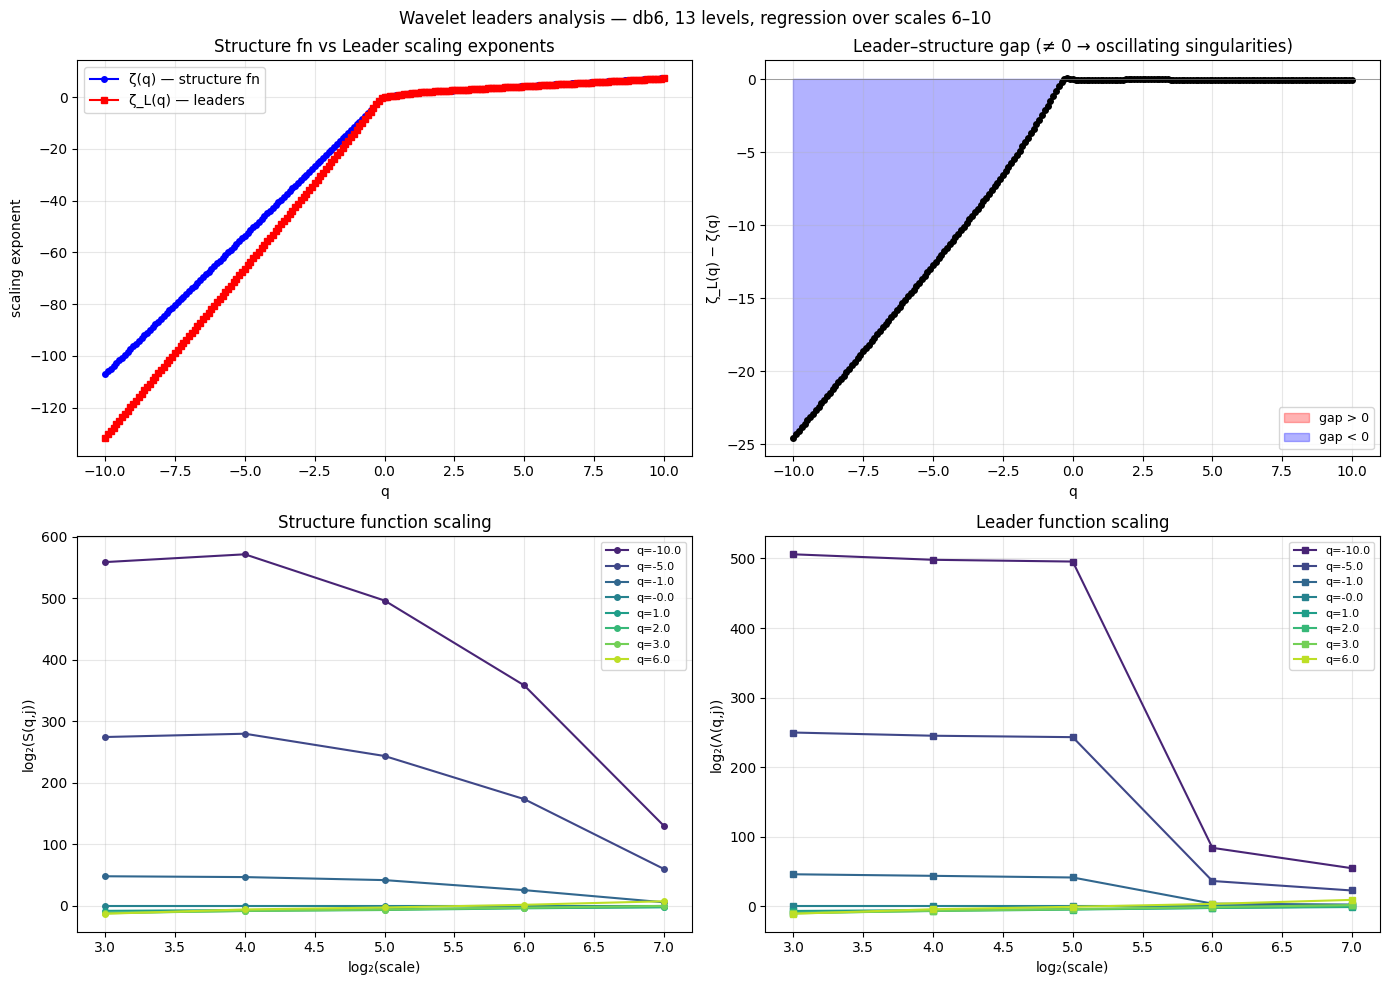

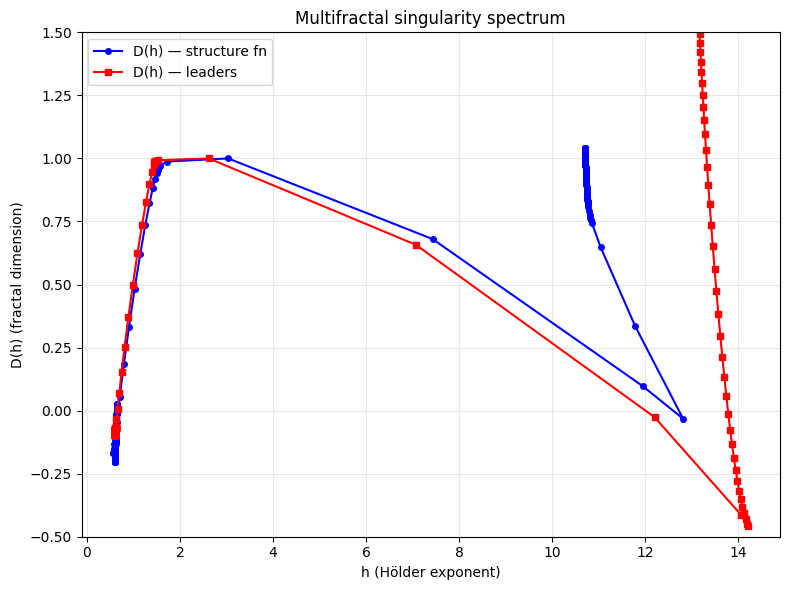


Scaling exponents:
q        ζ_S(q)       ζ_L(q)       gap         
--------------------------------------------
-10.0    -107.0735    -131.6364    -24.5629    
-9.9     -106.0032    -130.3288    -24.3256    
-9.8     -104.9329    -129.0212    -24.0884    
-9.7     -103.8625    -127.7137    -23.8512    
-9.6     -102.7922    -126.4063    -23.6141    
-9.5     -101.7218    -125.0989    -23.3771    
-9.4     -100.6515    -123.7916    -23.1401    
-9.3     -99.5811     -122.4844    -22.9033    
-9.2     -98.5108     -121.1772    -22.6665    
-9.1     -97.4404     -119.8701    -22.4297    
-9.0     -96.3700     -118.5631    -22.1931    
-8.9     -95.2996     -117.2561    -21.9565    
-8.8     -94.2292     -115.9492    -21.7200    
-8.7     -93.1588     -114.6424    -21.4835    
-8.6     -92.0884     -113.3356    -21.2471    
-8.5     -91.0180     -112.0288    -21.0108    
-8.4     -89.9476     -110.7221    -20.7745    
-8.3     -88.8772     -109.4155    -20.5383    
-8.2     -87.8067     -

In [6]:
# ---- Wavelet leaders: DWT-based multifractal analysis ----
# Compares structure function exponents ζ(q) vs leader exponents ζ_L(q).
# A gap between them signals oscillating singularities.

import pywt

# ---- Parameters ----
wavelet_dwt = 'db6'          # orthogonal wavelet
max_level = None              # None = max possible for signal length
q_values = np.arange(-10, 10.01, 0.1)  # moments to compute

# ---- DWT decomposition ----
coeffs = pywt.wavedec(x, wavelet_dwt, level=max_level)
# coeffs[0] = approximation, coeffs[1:] = details (coarsest → finest)
n_levels = len(coeffs) - 1
detail_coeffs = coeffs[1:]  # list of arrays, index 0 = coarsest

print(f"DWT: wavelet={wavelet_dwt}, {n_levels} levels")
for j, d in enumerate(detail_coeffs):
    scale_days = (2**(n_levels - j)) * dt / 86400
    print(f"  level {j+1}: {len(d)} coeffs, scale ≈ {scale_days:.2f} days")

# ---- Compute wavelet leaders ----
# Leader at (j, k) = sup of |d(j', k')| for j' <= j in a 3-neighbor window
# We work from finest to coarsest, propagating the running supremum.

# Start with absolute detail coefficients at each level
abs_details = [np.abs(d) for d in detail_coeffs]

# Leaders: initialize from the finest level, then propagate upward
leaders = [None] * n_levels

# Finest level: leader = max over 3-neighborhood of |d|
d_fin = abs_details[-1]
L_fin = np.maximum(np.maximum(
    np.roll(d_fin, 1), d_fin), np.roll(d_fin, -1))
# Fix boundary (don't wrap)
L_fin[0] = max(d_fin[0], d_fin[1])
L_fin[-1] = max(d_fin[-1], d_fin[-2])
leaders[-1] = L_fin

# Propagate coarser: at level j, leader = max(3-neighborhood of |d_j|,
#                     downsampled leaders from level j+1)
for j in range(n_levels - 2, -1, -1):
    d_j = abs_details[j]
    n_j = len(d_j)

    # 3-neighborhood sup of |d_j|
    L_j = np.maximum(np.maximum(
        np.roll(d_j, 1), d_j), np.roll(d_j, -1))
    L_j[0] = max(d_j[0], d_j[1])
    L_j[-1] = max(d_j[-1], d_j[-2])

    # Incorporate finer-scale leaders (downsample by 2 with max-pooling)
    L_fine = leaders[j + 1]
    n_fine = len(L_fine)
    # Each coarse position k corresponds to fine positions 2k, 2k+1
    n_use = min(n_j, n_fine // 2)
    for k in range(n_use):
        i_lo = max(0, 2*k - 1)
        i_hi = min(n_fine, 2*k + 3)
        L_j[k] = max(L_j[k], L_fine[i_lo:i_hi].max())

    leaders[j] = L_j

# ---- Structure functions S(q,j) and leader functions Λ(q,j) ----
# Use a range of scales, skip the finest 2 (noisy) and coarsest 2 (too few coeffs)
j_lo = 6   # skip finest scales
j_hi = min(n_levels - 2, n_levels)  # skip coarsest
j_range = np.arange(j_lo, j_hi)
scales_j = n_levels - j_range  # scale index (1 = finest)

# For regression we use log2(scale) as x-axis
log2_scales = scales_j.astype(float)

S_qj = np.zeros((len(q_values), len(j_range)))
L_qj = np.zeros((len(q_values), len(j_range)))

for qi, q in enumerate(q_values):
    for ji, j in enumerate(j_range):
        d = abs_details[j]
        L = leaders[j]
        # Avoid zero coefficients for negative q
        d_safe = np.clip(d, 1e-30, None)
        L_safe = np.clip(L, 1e-30, None)
        S_qj[qi, ji] = np.log2(np.mean(d_safe ** q))
        L_qj[qi, ji] = np.log2(np.mean(L_safe ** q))

# ---- Linear regression: ζ(q) and ζ_L(q) ----
zeta_S = np.zeros(len(q_values))
zeta_L = np.zeros(len(q_values))

for qi in range(len(q_values)):
    # S(q,j) ~ 2^(j * ζ(q)), so log2(S) = ζ(q) * j + const
    p_S = np.polyfit(log2_scales, S_qj[qi, :], 1)
    p_L = np.polyfit(log2_scales, L_qj[qi, :], 1)
    zeta_S[qi] = p_S[0]
    zeta_L[qi] = p_L[0]

# ---- Plot 1: ζ(q) comparison ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(q_values, zeta_S, 'b-o', ms=4, label='ζ(q) — structure fn')
axes[0, 0].plot(q_values, zeta_L, 'r-s', ms=4, label='ζ_L(q) — leaders')
axes[0, 0].set_xlabel('q')
axes[0, 0].set_ylabel('scaling exponent')
axes[0, 0].set_title('Structure fn vs Leader scaling exponents')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ---- Plot 2: gap ζ_L(q) - ζ(q) ----
gap = zeta_L - zeta_S
axes[0, 1].plot(q_values, gap, 'k-o', ms=4)
axes[0, 1].axhline(0, color='gray', linewidth=0.5)
axes[0, 1].set_xlabel('q')
axes[0, 1].set_ylabel('ζ_L(q) − ζ(q)')
axes[0, 1].set_title('Leader–structure gap (≠ 0 → oscillating singularities)')
axes[0, 1].grid(True, alpha=0.3)

# Shade the gap region
axes[0, 1].fill_between(q_values, 0, gap,
                         where=(gap > 0), alpha=0.3, color='red', label='gap > 0')
axes[0, 1].fill_between(q_values, 0, gap,
                         where=(gap < 0), alpha=0.3, color='blue', label='gap < 0')
axes[0, 1].legend(fontsize=9)

# ---- Plot 3: log-log scaling plots for a few q values ----
q_show = [-10, -5, -1, 0, 1, 2, 3, 6]
colors_q = plt.cm.viridis(np.linspace(0.1, 0.9, len(q_show)))
for qi_show, q_val in enumerate(q_show):
    qi = np.argmin(np.abs(q_values - q_val))
    axes[1, 0].plot(log2_scales, S_qj[qi, :], 'o-', color=colors_q[qi_show],
                     ms=4, label=f'q={q_values[qi]:.1f}')
axes[1, 0].set_xlabel('log₂(scale)')
axes[1, 0].set_ylabel('log₂(S(q,j))')
axes[1, 0].set_title('Structure function scaling')
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

for qi_show, q_val in enumerate(q_show):
    qi = np.argmin(np.abs(q_values - q_val))
    axes[1, 1].plot(log2_scales, L_qj[qi, :], 's-', color=colors_q[qi_show],
                     ms=4, label=f'q={q_values[qi]:.1f}')
axes[1, 1].set_xlabel('log₂(scale)')
axes[1, 1].set_ylabel('log₂(Λ(q,j))')
axes[1, 1].set_title('Leader function scaling')
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, alpha=0.3)

fig.suptitle(f'Wavelet leaders analysis — {wavelet_dwt}, {n_levels} levels, '
             f'regression over scales {j_lo}–{j_hi-1}', fontsize=12)
fig.tight_layout()
plt.show()

# ---- Multifractal spectrum via Legendre transform ----
# D(h) = min_q (qh - ζ(q) + 1)  — but easier via numerical Legendre
# h(q) = dζ/dq, D(q) = q*h(q) - ζ(q) + 1
dq = q_values[1] - q_values[0]

h_S = np.gradient(zeta_S, dq)
D_S = q_values * h_S - zeta_S + 1

h_L = np.gradient(zeta_L, dq)
D_L = q_values * h_L - zeta_L + 1

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(h_S, D_S, 'b-o', ms=4, label='D(h) — structure fn')
ax.plot(h_L, D_L, 'r-s', ms=4, label='D(h) — leaders')
ax.set_xlabel('h (Hölder exponent)')
ax.set_ylabel('D(h) (fractal dimension)')
ax.set_title('Multifractal singularity spectrum')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.5, 1.5)
fig.tight_layout()
plt.show()

# ---- Summary ----
print("\nScaling exponents:")
print(f"{'q':<8} {'ζ_S(q)':<12} {'ζ_L(q)':<12} {'gap':<12}")
print("-" * 44)
for qi, q in enumerate(q_values):
    print(f"{q:<8.1f} {zeta_S[qi]:<12.4f} {zeta_L[qi]:<12.4f} {gap[qi]:<12.4f}")

mean_gap = np.mean(np.abs(gap))
max_gap = np.max(np.abs(gap))
print(f"\nMean |gap|: {mean_gap:.4f}")
print(f"Max  |gap|: {max_gap:.4f}")
if max_gap > 0.1:
    print("→ Significant leader–structure gap detected: OSCILLATING SINGULARITIES likely present")
    print(f"  Estimated oscillation exponent β ≈ {np.mean(gap[q_values > 0]):.3f}")
else:
    print("→ No significant gap: singularities appear to be non-oscillating")

/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/mfanalysis/structurefunction.py:50: RuntimeWarning: divide by zero encountered in power
  s_j_q = np.mean(np.abs(c_j)**q)
/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/mfanalysis/cumulants.py:65: RuntimeWarning: divide by zero encountered in log
  log_T_X_j = np.log(T_X_j)
/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/mfanalysis/cumulants.py:76: RuntimeWarning: invalid value encountered in scalar subtract
  self.values[ind_m, ind_j] = moments[ind_m, ind_j] - aux
/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/mfanalysis/mfspectrum.py:57: RuntimeWarning: divide by zero encountered in power
  temp = np.power(mrq_values_j, qq)  # vector of size nj
/Users/amasaryk/miniforge/envs/wavelet/lib/python3.12/site-packages/mfanalysis/mfspectrum.py:59: RuntimeWarning: invalid value encountered in divide
  R_q_j = temp/temp.sum()
/Users/amasaryk/miniforge/envs/wavelet/l


hmin (leaders): 0.0362
hmin (p-leaders, p=1): 0.0362

Log-cumulants -- wavelet leaders (p=inf):
  c1 = 0.9260  (dominant Holder exponent)
  c2 = -0.0381  (multifractality)
  c3 = -0.5763  (asymmetry)

Log-cumulants -- p-leaders (p=1):
  c1 = 0.8399
  c2 = -0.0480
  c3 = -0.1602


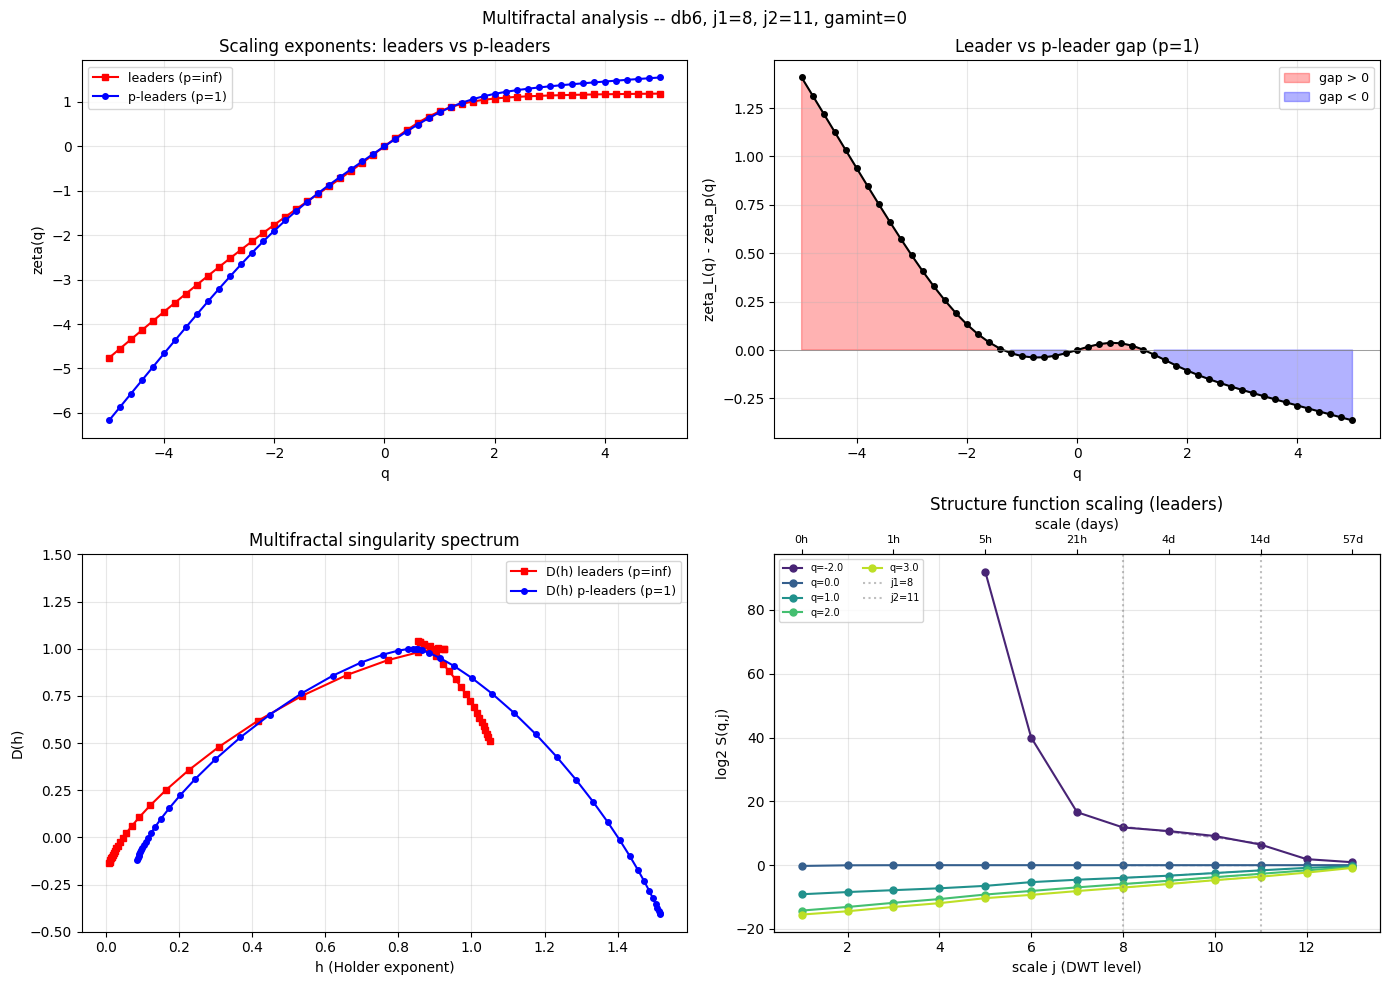


q        zeta_wl      zeta_pl      gap         
--------------------------------------------
-5.0     -4.7617      -6.1698      1.4081      
-4.8     -4.5521      -5.8669      1.3148      
-4.6     -4.3432      -5.5643      1.2210      
-4.4     -4.1352      -5.2623      1.1270      
-4.2     -3.9281      -4.9611      1.0330      
-4.0     -3.7220      -4.6612      0.9392      
-3.8     -3.5171      -4.3630      0.8460      
-3.6     -3.3134      -4.0672      0.7538      
-3.4     -3.1113      -3.7745      0.6631      
-3.2     -2.9111      -3.4856      0.5746      
-3.0     -2.7129      -3.2017      0.4888      
-2.8     -2.5172      -2.9239      0.4066      
-2.6     -2.3244      -2.6534      0.3290      
-2.4     -2.1348      -2.3915      0.2567      
-2.2     -1.9487      -2.1396      0.1909      
-2.0     -1.7662      -1.8987      0.1325      
-1.8     -1.5874      -1.6696      0.0822      
-1.6     -1.4119      -1.4524      0.0404      
-1.4     -1.2391      -1.2467      0.0076 

In [6]:
# ---- Multifractal analysis via mfanalysis (Wendt toolbox) ----
# https://github.com/omardrwch/mfanalysis
# Compares wavelet leaders (wlmf) vs p-leaders (p-leader) to detect

# oscillating singularities. p-leaders generalize leaders and can
# characterize the oscillation exponent β directly.

import mfanalysis as mf

# ---- Parameters ----
wt_name = 'db6'        # wavelet
j1 = 8                 # min scale (must be >= 1)
j2 = 11                # max scale (adjust after seeing DWT table)
q_range = np.arange(-5, 5.01, 0.2)
gamint = 0             # fractional integration (0 = none, try 1 if hmin <= 0)
p_exp = 1              # p for p-leaders (try 1, 2, or np.inf; np.inf = standard leaders)
dt_days = dt / 86400.0

# ---- Wavelet leader analysis (wlmf) ----
mfa_wl = mf.MFA()
mfa_wl.wt_name = wt_name
mfa_wl.q = q_range
mfa_wl.j1 = j1
mfa_wl.j2 = j2
mfa_wl.formalism = 'wlmf'
mfa_wl.gamint = gamint
mfa_wl.wtype = 0
mfa_wl.p = np.inf
mfa_wl.n_cumul = 3
mfa_wl.verbose = 1
mfa_wl.analyze(x)

# ---- p-leader analysis ----
mfa_pl = mf.MFA()
mfa_pl.wt_name = wt_name
mfa_pl.q = q_range
mfa_pl.j1 = j1
mfa_pl.j2 = j2
mfa_pl.formalism = 'p-leader'
mfa_pl.gamint = gamint
mfa_pl.wtype = 0
mfa_pl.p = p_exp
mfa_pl.n_cumul = 3
mfa_pl.verbose = 1
mfa_pl.analyze(x)

# ---- Extract results ----
zeta_wl = mfa_wl.structure.zeta
hq_wl = mfa_wl.spectrum.hq
Dq_wl = mfa_wl.spectrum.Dq
c1_wl, c2_wl, c3_wl = mfa_wl.cumulants.log_cumulants[:3]

zeta_pl = mfa_pl.structure.zeta
hq_pl = mfa_pl.spectrum.hq
Dq_pl = mfa_pl.spectrum.Dq
c1_pl, c2_pl, c3_pl = mfa_pl.cumulants.log_cumulants[:3]

print(f"\nhmin (leaders): {mfa_wl.hmin:.4f}")
print(f"hmin (p-leaders, p={p_exp}): {mfa_pl.hmin:.4f}")

print(f"\nLog-cumulants -- wavelet leaders (p=inf):")
print(f"  c1 = {c1_wl:.4f}  (dominant Holder exponent)")
print(f"  c2 = {c2_wl:.4f}  (multifractality)")
print(f"  c3 = {c3_wl:.4f}  (asymmetry)")

print(f"\nLog-cumulants -- p-leaders (p={p_exp}):")
print(f"  c1 = {c1_pl:.4f}")
print(f"  c2 = {c2_pl:.4f}")
print(f"  c3 = {c3_pl:.4f}")

# ---- Plot 1: Scaling exponents zeta(q) ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(q_range, zeta_wl, 'r-s', ms=4, label='leaders (p=inf)')
axes[0, 0].plot(q_range, zeta_pl, 'b-o', ms=4, label=f'p-leaders (p={p_exp})')
if 1.0 in q_range:
    idx1 = np.where(q_range == 1.0)[0][0]
    mono_line = q_range * zeta_wl[idx1]
    axes[0, 0].plot(q_range, mono_line, 'k--', alpha=0.4, label='monofractal ref')
axes[0, 0].set_xlabel('q')
axes[0, 0].set_ylabel('zeta(q)')
axes[0, 0].set_title('Scaling exponents: leaders vs p-leaders')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

# ---- Plot 2: Gap between leaders and p-leaders ----
gap = zeta_wl - zeta_pl
axes[0, 1].plot(q_range, gap, 'k-o', ms=4)
axes[0, 1].axhline(0, color='gray', linewidth=0.5)
axes[0, 1].fill_between(q_range, 0, gap,
                         where=(gap > 0), alpha=0.3, color='red', label='gap > 0')
axes[0, 1].fill_between(q_range, 0, gap,
                         where=(gap < 0), alpha=0.3, color='blue', label='gap < 0')
axes[0, 1].set_xlabel('q')
axes[0, 1].set_ylabel('zeta_L(q) - zeta_p(q)')
axes[0, 1].set_title(f'Leader vs p-leader gap (p={p_exp})')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

# ---- Plot 3: D(h) spectrum ----
axes[1, 0].plot(hq_wl, Dq_wl, 'r-s', ms=4, label='D(h) leaders (p=inf)')
axes[1, 0].plot(hq_pl, Dq_pl, 'b-o', ms=4, label=f'D(h) p-leaders (p={p_exp})')
axes[1, 0].set_xlabel('h (Holder exponent)')
axes[1, 0].set_ylabel('D(h)')
axes[1, 0].set_title('Multifractal singularity spectrum')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(-0.5, 1.5)

# ---- Plot 4: Structure function scaling — all scales ----
q_show = [-2, 0, 1, 2, 3]
colors_q = plt.cm.viridis(np.linspace(0.1, 0.9, len(q_show)))

# mfa_wl.structure.j = array of all scale indices
# mfa_wl.structure.logvalues = (n_q, n_j) array of log2(S(q,j))
j_all = np.array(mfa_wl.structure.j)
logvals = mfa_wl.structure.logvalues

for qi_show, qv in enumerate(q_show):
    qi = np.argmin(np.abs(q_range - qv))
    axes[1, 1].plot(j_all, logvals[qi, :], 'o-',
                     color=colors_q[qi_show], ms=5,
                     label=f'q={q_range[qi]:.1f}')
    # Regression line over j1-j2
    j_mask = (j_all >= j1) & (j_all <= j2)
    if j_mask.sum() >= 2:
        p_fit = np.polyfit(j_all[j_mask], logvals[qi, j_mask], 1)
        j_line = np.linspace(j_all[j_mask].min(), j_all[j_mask].max(), 50)
        axes[1, 1].plot(j_line, np.polyval(p_fit, j_line), '--',
                         color=colors_q[qi_show], alpha=0.5, linewidth=1)

# Mark regression range
axes[1, 1].axvline(j1, color='gray', linestyle=':', alpha=0.5, label=f'j1={j1}')
axes[1, 1].axvline(j2, color='gray', linestyle=':', alpha=0.5, label=f'j2={j2}')
axes[1, 1].set_xlabel('scale j (DWT level)')
axes[1, 1].set_ylabel('log2 S(q,j)')
axes[1, 1].set_title('Structure function scaling (leaders)')
axes[1, 1].legend(fontsize=7, ncol=2)
axes[1, 1].grid(True, alpha=0.3)

# Period labels on top axis
ax_top = axes[1, 1].twiny()
ax_top.set_xlim(axes[1, 1].get_xlim())
tick_j = j_all[::max(1, len(j_all)//6)]
ax_top.set_xticks(tick_j)
ax_top.set_xticklabels([f"{2**j * dt_days:.0f}d" if 2**j * dt_days >= 1
                         else f"{2**j * dt_days * 24:.0f}h" for j in tick_j], fontsize=8)
ax_top.set_xlabel('scale (days)')

fig.suptitle(f'Multifractal analysis -- {wt_name}, j1={j1}, j2={j2}, '
             f'gamint={gamint}', fontsize=12)
fig.tight_layout()
plt.show()

# ---- Summary ----
print(f"\n{'q':<8} {'zeta_wl':<12} {'zeta_pl':<12} {'gap':<12}")
print("-" * 44)
for qi, q in enumerate(q_range):
    print(f"{q:<8.1f} {zeta_wl[qi]:<12.4f} {zeta_pl[qi]:<12.4f} {gap[qi]:<12.4f}")

mean_gap = np.mean(np.abs(gap))
max_gap = np.max(np.abs(gap))
print(f"\nMean |gap|: {mean_gap:.4f}")
print(f"Max  |gap|: {max_gap:.4f}")

if max_gap > 0.05:
    q_pos = q_range[q_range > 0]
    gap_pos = gap[q_range > 0]
    beta_fit = np.polyfit(q_pos, gap_pos, 1)
    print(f"\n-> Gap detected between leaders and p-leaders")
    print(f"  Linear fit of gap vs q (q>0): slope = {beta_fit[0]:.4f}")
    print(f"  Estimated oscillation exponent beta ~ {beta_fit[0]:.3f}")
    if abs(beta_fit[0]) > 0.05:
        print(f"  -> OSCILLATING SINGULARITIES likely present (beta != 0)")
    else:
        print(f"  -> Gap may be due to finite-size effects, not oscillations")
else:
    print("-> No significant gap: leaders ~ p-leaders -> no oscillating singularities")

Top 10 scale ranges by linearity (mean R² across q):
Rank   j1    j2    scales   j1 period      j2 period      mean R²    min R²    
------------------------------------------------------------------------
1      4     7     4        3h             1d             nan        nan       
2      2     8     7        1h             2d             nan        nan       
3      3     11    9        1h             14d            nan        nan       
4      3     10    8        1h             7d             nan        nan       
5      3     9     7        1h             4d             nan        nan       
6      3     8     6        1h             2d             nan        nan       
7      3     7     5        1h             1d             nan        nan       
8      3     6     4        1h             0d             nan        nan       
9      2     13    12       1h             57d            nan        nan       
10     2     12    11       1h             28d            nan        nan  

/var/folders/k8/wqqjlxf115z79hdp7q2t162c0000gn/T/ipykernel_16593/1925318562.py:32: RuntimeWarning: invalid value encountered in subtract
  ss_tot = np.sum((y_reg - y_reg.mean())**2)


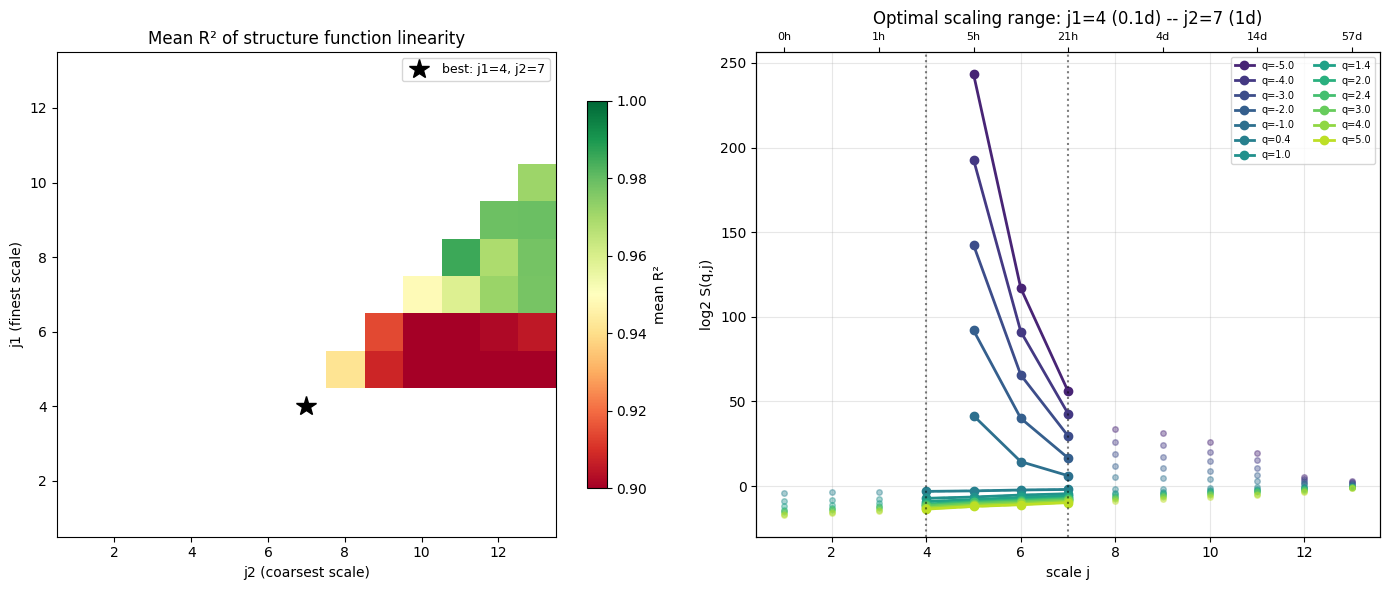


>>> Suggested: set j1=4, j2=7 in the multifractal analysis cell above


In [7]:
# ---- Optimal scale range selection for partition function ----
# Sweep all (j1, j2) pairs and evaluate how linear the structure
# function log2 S(q,j) is across that range. The best scaling range
# is where R² is highest across multiple q values.

# Use the leader structure function from the previous cell
j_all = np.array(mfa_wl.structure.j)
logvals = mfa_wl.structure.logvalues  # (n_q, n_j)
n_j = len(j_all)

# q values to evaluate linearity over (skip q=0 which is trivially linear)
q_eval = [-5, -4, -3, -2, -1, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4, 5]
q_eval_idx = [np.argmin(np.abs(q_range - qv)) for qv in q_eval]

min_points = 4  # minimum number of scales in regression

# Sweep all (j1, j2) pairs
results = []
for i1 in range(n_j):
    for i2 in range(i1 + min_points - 1, n_j):
        j1_try = j_all[i1]
        j2_try = j_all[i2]
        n_pts = i2 - i1 + 1

        x_reg = j_all[i1:i2+1].astype(float)
        r2_list = []
        for qi in q_eval_idx:
            y_reg = logvals[qi, i1:i2+1]
            p = np.polyfit(x_reg, y_reg, 1)
            y_fit = np.polyval(p, x_reg)
            ss_res = np.sum((y_reg - y_fit)**2)
            ss_tot = np.sum((y_reg - y_reg.mean())**2)
            r2 = 1 - ss_res / (ss_tot + 1e-30)
            r2_list.append(r2)

        mean_r2 = np.mean(r2_list)
        min_r2 = np.min(r2_list)
        results.append((j1_try, j2_try, n_pts, mean_r2, min_r2))

results = np.array(results)

# ---- Find best ranges ----
# Rank by mean R², but penalize very short ranges
scores = results[:, 3] * (1 - 1.0 / results[:, 2])  # mean_r2 * (1 - 1/n_pts)
best_idx = np.argsort(scores)[::-1]

print("Top 10 scale ranges by linearity (mean R² across q):")
print(f"{'Rank':<6} {'j1':<5} {'j2':<5} {'scales':<8} "
      f"{'j1 period':<14} {'j2 period':<14} {'mean R²':<10} {'min R²':<10}")
print("-" * 72)
for rank, idx in enumerate(best_idx[:10]):
    j1_r, j2_r, n_pts, mean_r2, min_r2 = results[idx]
    p1 = 2**j1_r * dt_days
    p2 = 2**j2_r * dt_days
    p1_str = f"{p1:.1f}d" if p1 >= 1 else f"{p1*24:.0f}h"
    p2_str = f"{p2/365:.1f}yr" if p2 >= 365 else f"{p2:.0f}d"
    print(f"{rank+1:<6} {int(j1_r):<5} {int(j2_r):<5} {int(n_pts):<8} "
          f"{p1_str:<14} {p2_str:<14} {mean_r2:<10.6f} {min_r2:<10.6f}")

# ---- Heatmap: mean R² for all (j1, j2) pairs ----
j_min, j_max = int(j_all.min()), int(j_all.max())
r2_map = np.full((j_max - j_min + 1, j_max - j_min + 1), np.nan)
for j1_r, j2_r, n_pts, mean_r2, min_r2 in results:
    r2_map[int(j1_r) - j_min, int(j2_r) - j_min] = mean_r2

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im = axes[0].imshow(r2_map, origin='lower', cmap='RdYlGn',
                     extent=[j_min-0.5, j_max+0.5, j_min-0.5, j_max+0.5],
                     aspect='auto', vmin=0.9, vmax=1.0)
axes[0].set_xlabel('j2 (coarsest scale)')
axes[0].set_ylabel('j1 (finest scale)')
axes[0].set_title('Mean R² of structure function linearity')
fig.colorbar(im, ax=axes[0], label='mean R²', shrink=0.8)

# Mark the best range
best = results[best_idx[0]]
axes[0].plot(best[1], best[0], 'k*', ms=15, label=f'best: j1={int(best[0])}, j2={int(best[1])}')
axes[0].legend(fontsize=9)

# ---- Plot: structure function with optimal range highlighted ----
j1_opt, j2_opt = int(best[0]), int(best[1])
i1_opt = np.where(j_all == j1_opt)[0][0]
i2_opt = np.where(j_all == j2_opt)[0][0]

colors_q2 = plt.cm.viridis(np.linspace(0.1, 0.9, len(q_eval)))
for qi_show, qv in enumerate(q_eval):
    qi = q_eval_idx[qi_show]
    axes[1].plot(j_all, logvals[qi, :], 'o', color=colors_q2[qi_show],
                 ms=4, alpha=0.4)
    # Highlight optimal range
    axes[1].plot(j_all[i1_opt:i2_opt+1], logvals[qi, i1_opt:i2_opt+1], 'o-',
                 color=colors_q2[qi_show], ms=6, linewidth=2,
                 label=f'q={q_range[qi]:.1f}')
    # Regression line
    p = np.polyfit(j_all[i1_opt:i2_opt+1].astype(float),
                   logvals[qi, i1_opt:i2_opt+1], 1)
    j_line = np.linspace(j1_opt, j2_opt, 50)
    axes[1].plot(j_line, np.polyval(p, j_line), '--',
                 color=colors_q2[qi_show], alpha=0.6)

axes[1].axvline(j1_opt, color='k', linestyle=':', alpha=0.5)
axes[1].axvline(j2_opt, color='k', linestyle=':', alpha=0.5)
axes[1].set_xlabel('scale j')
axes[1].set_ylabel('log2 S(q,j)')
axes[1].set_title(f'Optimal scaling range: j1={j1_opt} ({2**j1_opt*dt_days:.1f}d) -- '
                   f'j2={j2_opt} ({2**j2_opt*dt_days:.0f}d)')
axes[1].legend(fontsize=7, ncol=2)
axes[1].grid(True, alpha=0.3)

# Period labels
ax_t = axes[1].twiny()
ax_t.set_xlim(axes[1].get_xlim())
tick_j = j_all[::max(1, len(j_all)//6)]
ax_t.set_xticks(tick_j)
ax_t.set_xticklabels([f"{2**j*dt_days:.0f}d" if 2**j*dt_days >= 1
                       else f"{2**j*dt_days*24:.0f}h" for j in tick_j], fontsize=8)

fig.tight_layout()
plt.show()

print(f"\n>>> Suggested: set j1={j1_opt}, j2={j2_opt} in the multifractal analysis cell above")

## Cell 2 – SSQ-CWT with physical units

Passing `fs=` to `ssq_cwt` makes `ssq_freqs` come back in **Hz**.
We convert to **cycles/day** (cpd) for geophysical interpretation.

### Scale grid: octaves and voices
- `scales='log'` gives a dyadic grid: `2^(j/nv)` for j = 0, 1, ..., J*nv
- `scales='log:maximal'` extends to the widest range the signal length supports
- `nv=32` → 32 voices per octave (wavelets per frequency-doubling)
- Higher `nv` = finer frequency resolution but more computation
- The number of **octaves** J is chosen automatically based on `scales` mode

In [9]:
from ssqueezepy.wavelets import center_frequency

wavelet = "morlet"
nv = 16  # voices per octave — 16 is a good speed/resolution tradeoff

Tx, Wx, ssq_freqs, scales = ssq_cwt(
    x,
    wavelet=wavelet,
    scales='log:maximal',
    nv=nv,
    fs=fs,
    padtype='reflect',
    maprange='maximal',
)

# convert to cycles per day
freq_cpd = ssq_freqs * 86400.0
A = np.abs(Tx)

# CWT scale-derived frequencies for comparison
cf_lo = center_frequency(wavelet, scale=scales[-1], N=N) * fs / (2 * np.pi)
cf_hi = center_frequency(wavelet, scale=scales[0],  N=N) * fs / (2 * np.pi)

n_octaves = np.log2(scales[-1] / scales[0])
print(f"Tx shape: {Tx.shape}, Wx shape: {Wx.shape}")
print(f"scales: {len(scales)} total, {n_octaves:.1f} octaves, {nv} voices/octave")
print(f"CWT scale freqs:  {cf_lo*86400:.4f} – {cf_hi*86400:.4f} cpd")
print(f"SSQ freq grid:    {freq_cpd.min():.4f} – {freq_cpd.max():.4f} cpd")

: 

In [8]:
from ssqueezepy import Wavelet
from ssqueezepy.utils import make_scales
from ssqueezepy.wavelets import center_frequency

wavelet_obj = Wavelet('morlet')

# Target freq range in cpd — change these to zoom into any band
f_hi_cpd = 12       # high-freq bound (cpd)
f_lo_cpd = 0.0325   # low-freq bound (cpd)

f_hi_hz = f_hi_cpd / 86400.0
f_lo_hz = f_lo_cpd / 86400.0

# Scale ↔ frequency: f_Hz = mu·fs / (2π·a), so a = mu·fs / (2π·f_Hz)
mu = wavelet_obj.wc_ct
s_lo = mu * fs / (2 * np.pi * f_hi_hz)   # high freq → low scale
s_hi = mu * fs / (2 * np.pi * f_lo_hz)   # low freq → high scale

# Build dyadic scale grid: 2^(j/nv) — the format ssqueezepy expects
scales_custom = make_scales(N, min_scale=s_lo, max_scale=s_hi, nv=nv,
                            scaletype='log')

n_octaves_band = np.log2(s_hi / s_lo)
print(f"mu = {mu:.4f}, s_lo = {s_lo:.1f}, s_hi = {s_hi:.1f}")
print(f"Band spans {n_octaves_band:.2f} octaves, {len(scales_custom)} scales "
      f"at {nv} voices/octave")

Tx, Wx, ssq_freqs, scales = ssq_cwt(
    x, wavelet=wavelet, scales=scales_custom,
    nv=nv, fs=fs, padtype='reflect',
)

# Scale-derived frequencies in cpd (always finite, one per CWT row)
scale_freq_cpd = mu * fs / (2 * np.pi * scales) * 86400.0

# SSQ freq grid in cpd (for row-based band selection in issq_cwt)
freq_cpd = ssq_freqs * 86400.0

A = np.abs(Tx)
Aw = np.abs(Wx)

n_octaves = np.log2(scales[-1] / scales[0])
print(f"\nTx shape: {Tx.shape}  (SSQ bins × time)")
print(f"Wx shape: {Wx.shape}  (scales × time)")
print(f"scales: {len(scales)} total, {n_octaves:.1f} octaves, {nv} voices/octave")
print(f"Scale freq range: {scale_freq_cpd.min():.4f} – {scale_freq_cpd.max():.4f} cpd")
print(f"Target:           {f_lo_cpd:.4f} – {f_hi_cpd:.4f} cpd")

: 

## Cell 3 – Scalogram in cycles/day

Expected tidal lines:
| Name | cpd   |
|------|-------|
| O1   | 0.930 |
| K1   | 1.003 |
| M2   | 1.932 |
| S2   | 2.000 |

In [ ]:
from ssqueezepy.visuals import imshow

cmap = 'turbo'  # try: 'turbo', 'magma', 'inferno', 'viridis', 'hot', 'cubehelix'

# ---- SSQ scalogram using ssqueezepy's imshow ----
# Rows are already log-spaced (dyadic scales), so linear y-axis = log frequency
fig, ax = plt.subplots(figsize=(15, 6))
imshow(Tx, abs=1, cmap=cmap, ax=ax, fig=fig, show=0,
       title='SSQ-CWT scalogram – XMR1',
       yticks=scale_freq_cpd, ylabel='freq (cpd)',
       xticks=t_days, xlabel='time (days)')
fig.tight_layout()
plt.show()

# ---- CWT scalogram for comparison ----
fig, ax = plt.subplots(figsize=(15, 6))
imshow(Wx, abs=1, cmap=cmap, ax=ax, fig=fig, show=0,
       title='CWT scalogram – XMR1',
       yticks=scale_freq_cpd, ylabel='freq (cpd)',
       xticks=t_days, xlabel='time (days)')
fig.tight_layout()
plt.show()

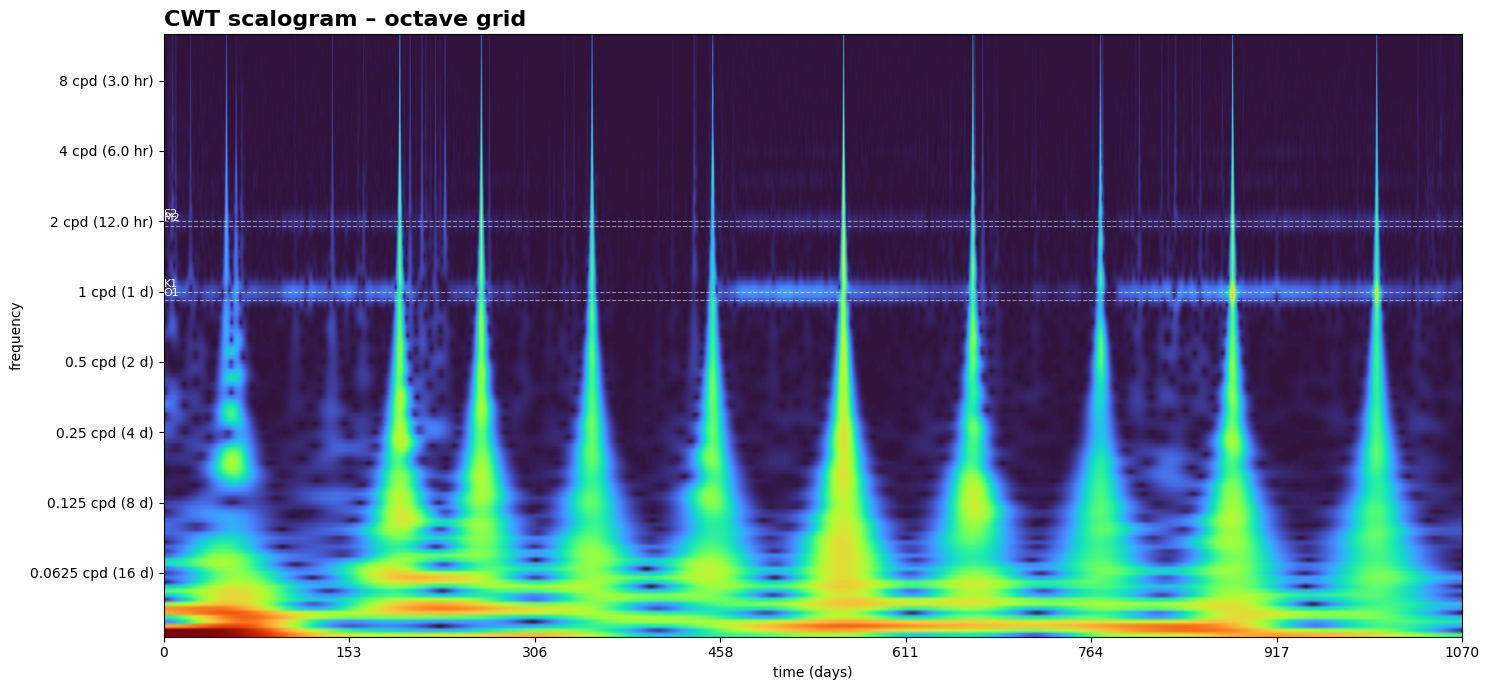


Octave   cpd          Period      
--------------------------------
2^-4     0.0625       16.0 days
2^-3     0.125        8.0 days
2^-2     0.25         4.0 days
2^-1     0.5          2.0 days
2^+0     1            1.0 days
2^+1     2            12.0 hours
2^+2     4            6.0 hours
2^+3     8            3.0 hours


In [76]:
# ---- Scalogram with octave labels ----
import math

fig, ax = plt.subplots(figsize=(15, 7))
imshow(Wx, abs=1, ax=ax, fig=fig, show=0,
       title='CWT scalogram – octave grid')

# Build octave tick labels from scale-derived frequencies
f_lo, f_hi = scale_freq_cpd.min(), scale_freq_cpd.max()
oct_min = math.floor(math.log2(f_lo))
oct_max = math.ceil(math.log2(f_hi))
octave_cpds = [2.0**i for i in range(oct_min, oct_max + 1) if f_lo <= 2.0**i <= f_hi]

# Map each octave frequency to the closest row index in the CWT
tick_positions = []
tick_labels = []
for f in octave_cpds:
    row = np.argmin(np.abs(scale_freq_cpd - f))
    period = 1.0 / f
    if period >= 365:
        period_str = f"{period/365:.1f} yr"
    elif period >= 1:
        period_str = f"{period:.0f} d"
    else:
        period_str = f"{period*24:.1f} hr"
    tick_positions.append(row)
    tick_labels.append(f"{f:.4g} cpd ({period_str})")

ax.set_yticks(tick_positions)
ax.set_yticklabels(tick_labels)

# annotate tidal frequencies
tidal = {'O1': 0.930, 'K1': 1.003, 'M2': 1.932, 'S2': 2.000}
for name, f in tidal.items():
    if f_lo <= f <= f_hi:
        row = np.argmin(np.abs(scale_freq_cpd - f))
        ax.axhline(row, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
        ax.text(5, row - 1, name, color='white', fontsize=8)

# time axis ticks
t_idxs = np.linspace(0, len(t_days) - 1, 8).astype(int)
ax.set_xticks(t_idxs)
ax.set_xticklabels([f"{t_days[i]:.0f}" for i in t_idxs])
ax.set_xlabel('time (days)')
ax.set_ylabel('frequency')

fig.tight_layout()
plt.show()

# print octave table
print(f"\n{'Octave':<8} {'cpd':<12} {'Period':<12}")
print("-" * 32)
for f in octave_cpds:
    period = 1.0 / f
    if period >= 365:
        period_str = f"{period/365:.1f} yr"
    elif period >= 1:
        period_str = f"{period:.1f} days"
    else:
        period_str = f"{period*24:.1f} hours"
    print(f"2^{math.log2(f):+.0f}     {f:<12.4g} {period_str}")

Band: 0.3–3 cpd → rows 33–86 (center=59, half_bw=26)
Actual freq range: 2.984–0.301 cpd


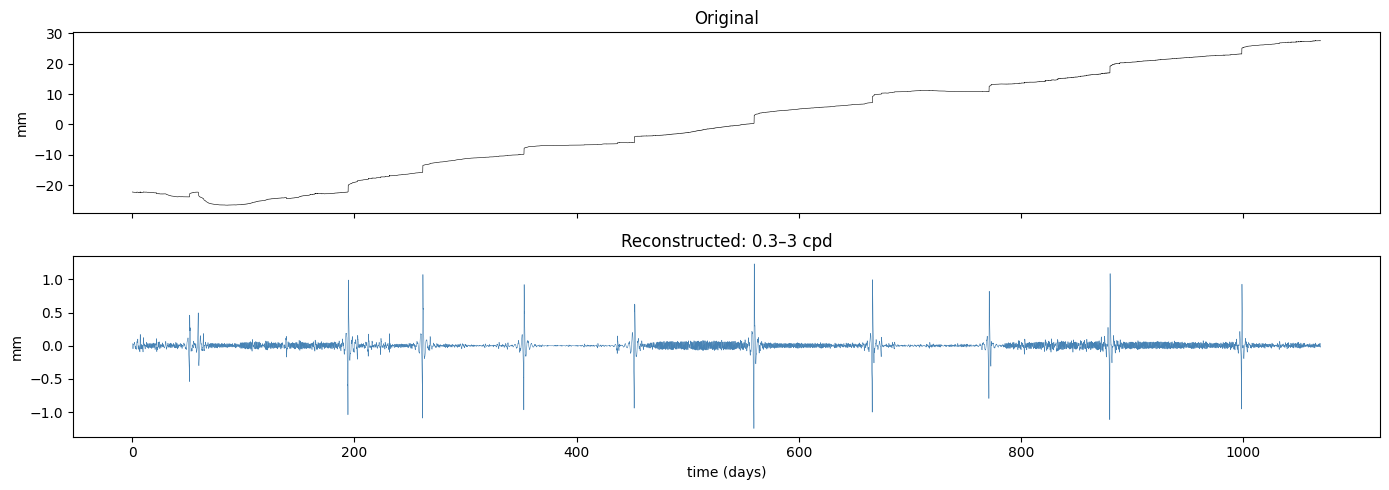

In [77]:
# ---- Inverse SSQ-CWT for a chosen frequency band ----
# Set your band in cycles/day:
band_lo_cpd =0.3    # lower bound
band_hi_cpd =  3    # upper bound

# find row indices in Tx corresponding to this band
row_lo = np.argmin(np.abs(freq_cpd - band_lo_cpd))
row_hi = np.argmin(np.abs(freq_cpd - band_hi_cpd))
if row_lo > row_hi:
    row_lo, row_hi = row_hi, row_lo

center = (row_lo + row_hi) // 2
half_bw = (row_hi - row_lo) // 2
n_time = Tx.shape[1]

cc = np.full(n_time, center, dtype=np.int32)
cw = np.full(n_time, half_bw, dtype=np.int32)

x_band = issq_cwt(Tx, wavelet, cc=cc, cw=cw)
x_band_signal = np.real(x_band[0])

print(f"Band: {band_lo_cpd}–{band_hi_cpd} cpd → rows {row_lo}–{row_hi} "
      f"(center={center}, half_bw={half_bw})")
print(f"Actual freq range: {freq_cpd[row_lo]:.3f}–{freq_cpd[row_hi]:.3f} cpd")

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t_days, x, linewidth=0.4, color='k')
axes[0].set_ylabel('mm')
axes[0].set_title('Original')

axes[1].plot(t_days, x_band_signal, linewidth=0.4, color='steelblue')
axes[1].set_ylabel('mm')
axes[1].set_title(f'Reconstructed: {band_lo_cpd}–{band_hi_cpd} cpd')

axes[-1].set_xlabel('time (days)')
fig.tight_layout()
plt.show()

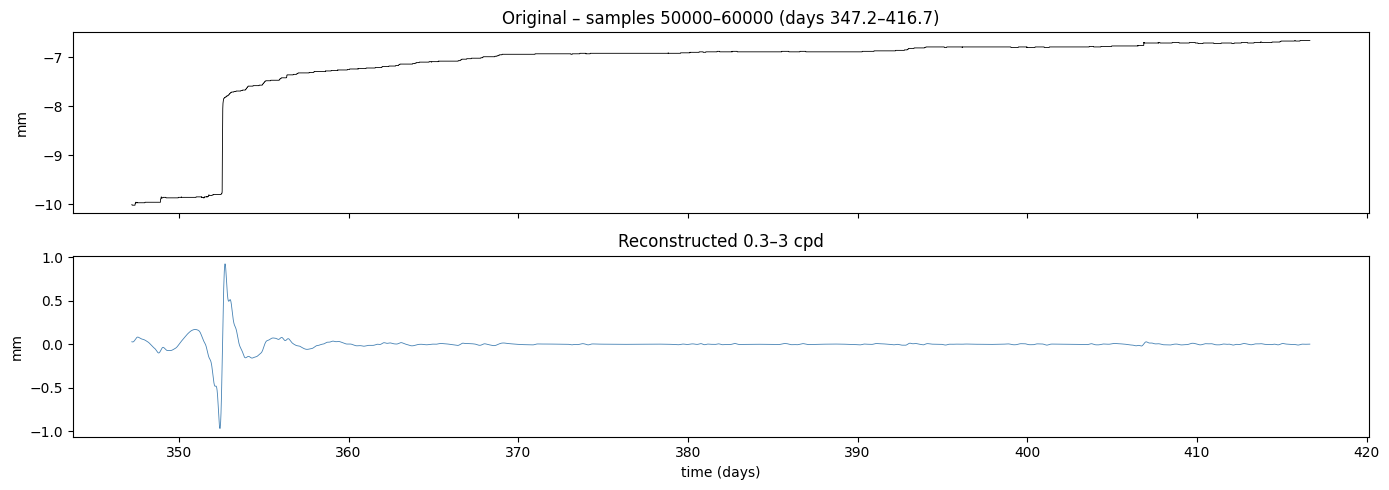

In [78]:
# ---- Zoom into a sample range ----
i_start = 50000   # start sample index
i_end   = 60000   # end sample index

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t_days[i_start:i_end], x[i_start:i_end], linewidth=0.6, color='k')
axes[0].set_ylabel('mm')
axes[0].set_title(f'Original – samples {i_start}–{i_end} (days {t_days[i_start]:.1f}–{t_days[i_end]:.1f})')

axes[1].plot(t_days[i_start:i_end], x_band_signal[i_start:i_end], linewidth=0.6, color='steelblue')
axes[1].set_ylabel('mm')
axes[1].set_title(f'Reconstructed {band_lo_cpd}–{band_hi_cpd} cpd')

axes[-1].set_xlabel('time (days)')
fig.tight_layout()
plt.show()

Scott's rule: h = 0.0051, n_bins = 484


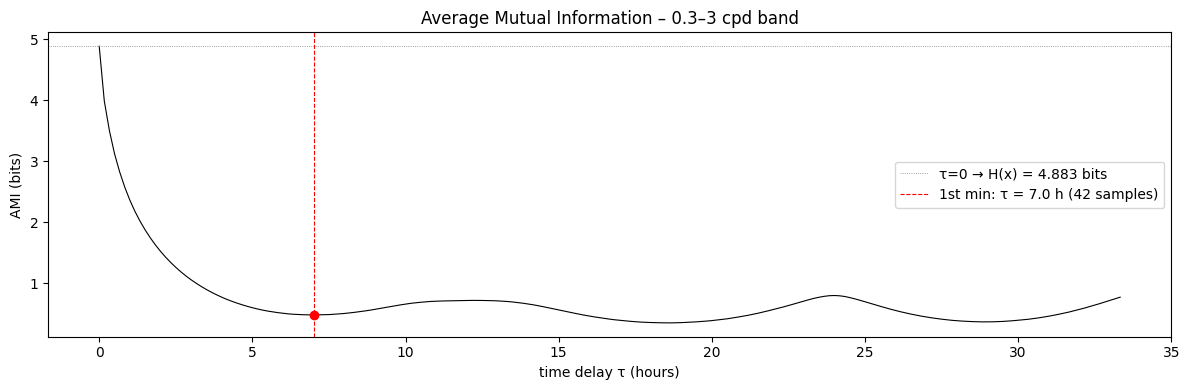


→ Suggested embedding delay: τ = 42 samples = 7.0 hours


In [79]:
# ---- Average Mutual Information (AMI) vs time delay ----
# Fraser & Swinney (1986): choose τ at first minimum of AMI.
# At τ = 0, AMI = Shannon entropy H(x) = -Σ p(x) log p(x).
# Bin width follows Scott's rule: h = 3.49 σ N^{-1/3}

def average_mutual_information(x, tau, n_bins):
    """Compute AMI between x(t) and x(t+τ) using histogram estimator."""
    x1 = x[:-tau] if tau > 0 else x
    x2 = x[tau:]  if tau > 0 else x

    # joint and marginal histograms
    H_joint, xedges, yedges = np.histogram2d(x1, x2, bins=n_bins)
    H_joint = H_joint / H_joint.sum()          # joint pdf p(x,y)

    px = H_joint.sum(axis=1)                    # marginal p(x)
    py = H_joint.sum(axis=0)                    # marginal p(y)

    # AMI = Σ p(x,y) log[ p(x,y) / (p(x)p(y)) ]
    # At τ=0 the joint is the diagonal → AMI = H(x) (Shannon entropy)
    nz = H_joint > 0
    ami = np.sum(
        H_joint[nz] * np.log2(H_joint[nz] / (px[:, None] * py[None, :])[nz])
    )
    return ami

# Scott's rule for bin width: h = 3.49 σ N^{-1/3}
s = x_band_signal
sigma = np.std(s)
h_scott = 3.49 * sigma * len(s) ** (-1.0 / 3)
n_bins = max(int(np.ceil((s.max() - s.min()) / h_scott)), 8)
print(f"Scott's rule: h = {h_scott:.4f}, n_bins = {n_bins}")

# scan τ from 0 to ~3 days (432 samples at 10-min)
tau_max = 200
taus = np.arange(0, tau_max + 1, 1)
ami_values = np.array([average_mutual_information(s, t, n_bins) for t in taus])
tau_hours = taus * 10.0 / 60.0   # convert samples → hours

# find first local minimum
from scipy.signal import argrelmin
local_mins = argrelmin(ami_values, order=5)[0]
first_min_tau = local_mins[0] if len(local_mins) > 0 else None

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_hours, ami_values, 'k-', linewidth=0.8)
ax.axhline(ami_values[0], color='grey', linestyle=':', linewidth=0.6,
           label=f'τ=0 → H(x) = {ami_values[0]:.3f} bits')
if first_min_tau is not None:
    ax.axvline(tau_hours[first_min_tau], color='red', linestyle='--', linewidth=0.8,
               label=f'1st min: τ = {tau_hours[first_min_tau]:.1f} h ({first_min_tau} samples)')
    ax.plot(tau_hours[first_min_tau], ami_values[first_min_tau], 'ro', ms=6)
ax.set_xlabel('time delay τ (hours)')
ax.set_ylabel('AMI (bits)')
ax.set_title(f'Average Mutual Information – {band_lo_cpd}–{band_hi_cpd} cpd band')
ax.legend()
fig.tight_layout()
plt.show()

if first_min_tau is not None:
    print(f"\n→ Suggested embedding delay: τ = {first_min_tau} samples "
          f"= {tau_hours[first_min_tau]:.1f} hours")
else:
    print("\nNo local minimum found — try increasing tau_max")

Delay τ = 43 samples = 7.2 hours
Embedding: 7914 points in 3D


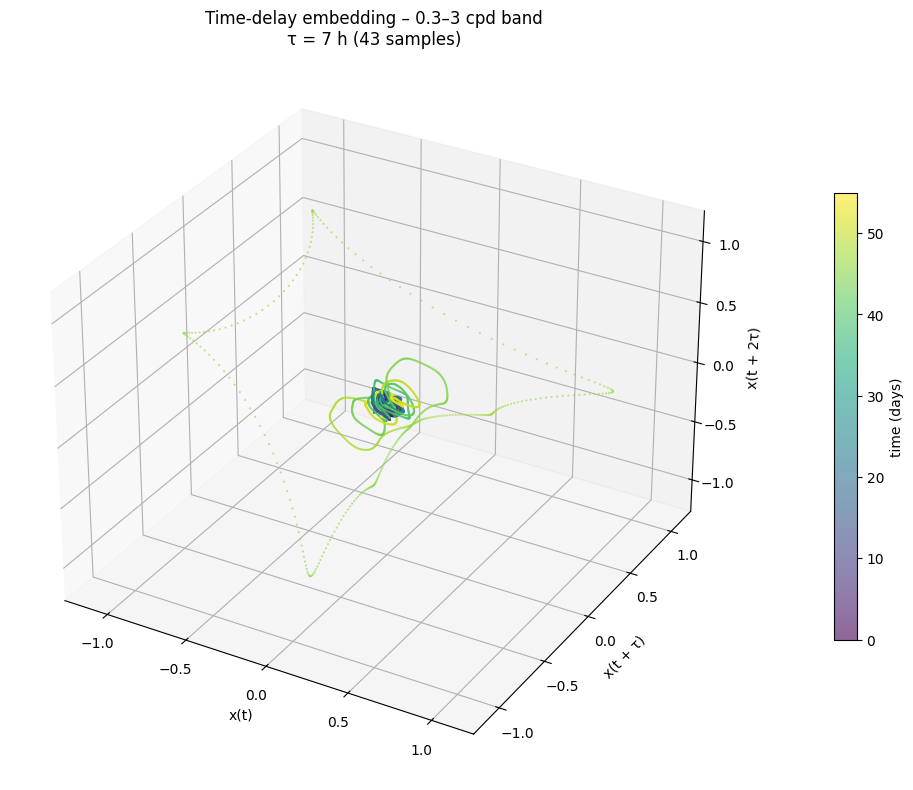

In [80]:
# ---- Time-delay embedding of the reconstructed band signal ----
# Embed x_band_signal in 3D using Takens' delay embedding theorem.
# Adjust `tau` (delay in samples) and `downsample` to taste.

from mpl_toolkits.mplot3d import Axes3D

# ---- parameters ----
tau = 43          # delay in samples (144 × 10 min = 1 day for tidal; adjust as needed)
downsample = 1     # plot every Nth point (increase if too slow)

# build delay vectors: [x(t), x(t+tau), x(t+2*tau)]
s = x_band_signal[120000:128000]
max_idx = len(s) - 2 * tau
X_emb = np.column_stack([s[:max_idx], s[tau:max_idx + tau], s[2*tau:max_idx + 2*tau]])
t_emb = t_days[:max_idx]

print(f"Delay τ = {tau} samples = {tau * dt / 3600:.1f} hours")
print(f"Embedding: {X_emb.shape[0]} points in 3D")

# ---- 3D scatter plot colored by time ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ds = downsample
sc = ax.scatter(
    X_emb[::ds, 0], X_emb[::ds, 1], X_emb[::ds, 2],
    c=t_emb[::ds], cmap='viridis', s=0.3, alpha=0.6,
)
ax.set_xlabel(f'x(t)')
ax.set_ylabel(f'x(t + τ)')
ax.set_zlabel(f'x(t + 2τ)')
ax.set_title(f'Time-delay embedding – {band_lo_cpd}–{band_hi_cpd} cpd band\n'
             f'τ = {tau * dt / 3600:.0f} h ({tau} samples)')

fig.colorbar(sc, ax=ax, label='time (days)', shrink=0.6, pad=0.1)
fig.tight_layout()
plt.show()

Band: 0.003906–0.0625 cpd → rows 122–136 (center=129, half_bw=7)
Actual freq range: 0.063–0.035 cpd


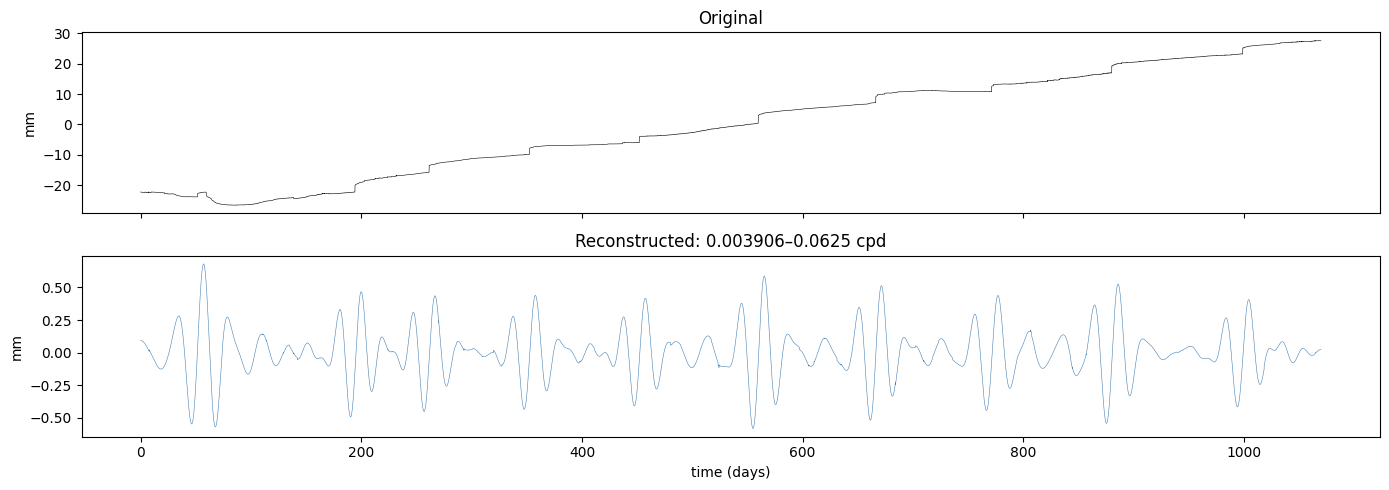

In [81]:
# ---- Inverse SSQ-CWT for a chosen frequency band ----
# Set your band in cycles/day:
band_lo_cpd =0.003906    # lower bound
band_hi_cpd =  .0625    # upper bound

# find row indices in Tx corresponding to this band
row_lo = np.argmin(np.abs(freq_cpd - band_lo_cpd))
row_hi = np.argmin(np.abs(freq_cpd - band_hi_cpd))
if row_lo > row_hi:
    row_lo, row_hi = row_hi, row_lo

center = (row_lo + row_hi) // 2
half_bw = (row_hi - row_lo) // 2
n_time = Tx.shape[1]

cc = np.full(n_time, center, dtype=np.int32)
cw = np.full(n_time, half_bw, dtype=np.int32)

x_band = issq_cwt(Tx, wavelet, cc=cc, cw=cw)
x_band_signal = np.real(x_band[0])

print(f"Band: {band_lo_cpd}–{band_hi_cpd} cpd → rows {row_lo}–{row_hi} "
      f"(center={center}, half_bw={half_bw})")
print(f"Actual freq range: {freq_cpd[row_lo]:.3f}–{freq_cpd[row_hi]:.3f} cpd")

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t_days, x, linewidth=0.4, color='k')
axes[0].set_ylabel('mm')
axes[0].set_title('Original')

axes[1].plot(t_days, x_band_signal, linewidth=0.4, color='steelblue')
axes[1].set_ylabel('mm')
axes[1].set_title(f'Reconstructed: {band_lo_cpd}–{band_hi_cpd} cpd')

axes[-1].set_xlabel('time (days)')
fig.tight_layout()
plt.show()

Scott's rule: h = 0.0127, n_bins = 100


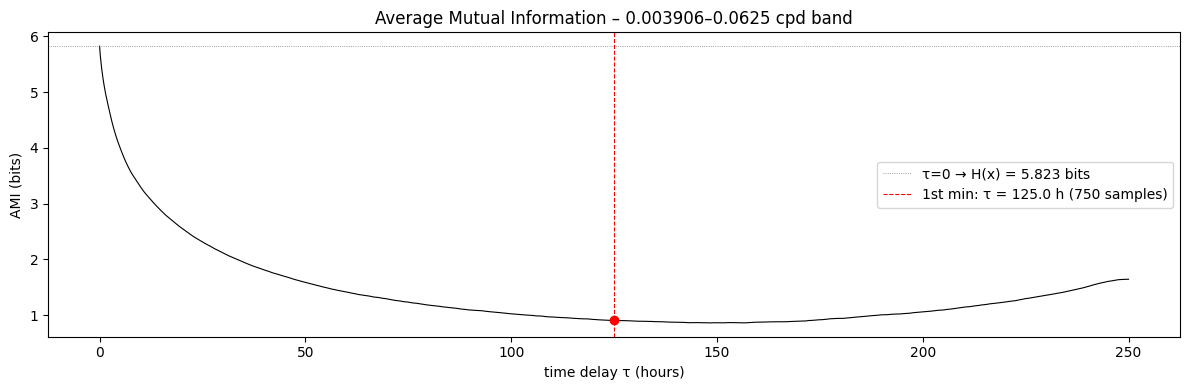


→ Suggested embedding delay: τ = 750 samples = 125.0 hours


In [82]:
# ---- Average Mutual Information (AMI) vs time delay ----
# Fraser & Swinney (1986): choose τ at first minimum of AMI.
# At τ = 0, AMI = Shannon entropy H(x) = -Σ p(x) log p(x).
# Bin width follows Scott's rule: h = 3.49 σ N^{-1/3}

def average_mutual_information(x, tau, n_bins):
    """Compute AMI between x(t) and x(t+τ) using histogram estimator."""
    x1 = x[:-tau] if tau > 0 else x
    x2 = x[tau:]  if tau > 0 else x

    # joint and marginal histograms
    H_joint, xedges, yedges = np.histogram2d(x1, x2, bins=n_bins)
    H_joint = H_joint / H_joint.sum()          # joint pdf p(x,y)

    px = H_joint.sum(axis=1)                    # marginal p(x)
    py = H_joint.sum(axis=0)                    # marginal p(y)

    # AMI = Σ p(x,y) log[ p(x,y) / (p(x)p(y)) ]
    # At τ=0 the joint is the diagonal → AMI = H(x) (Shannon entropy)
    nz = H_joint > 0
    ami = np.sum(
        H_joint[nz] * np.log2(H_joint[nz] / (px[:, None] * py[None, :])[nz])
    )
    return ami

# Scott's rule for bin width: h = 3.49 σ N^{-1/3}
s = x_band_signal
sigma = np.std(s)
h_scott = 3.49 * sigma * len(s) ** (-1.0 / 3)
n_bins = max(int(np.ceil((s.max() - s.min()) / h_scott)), 8)
print(f"Scott's rule: h = {h_scott:.4f}, n_bins = {n_bins}")

# scan τ from 0 to ~3 days (432 samples at 10-min)
tau_max = 1500
taus = np.arange(0, tau_max + 1, 1)
ami_values = np.array([average_mutual_information(s, t, n_bins) for t in taus])
tau_hours = taus * 10.0 / 60.0   # convert samples → hours

# find first local minimum
from scipy.signal import argrelmin
local_mins = argrelmin(ami_values, order=5)[0]
first_min_tau = local_mins[0] if len(local_mins) > 0 else None

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_hours, ami_values, 'k-', linewidth=0.8)
ax.axhline(ami_values[0], color='grey', linestyle=':', linewidth=0.6,
           label=f'τ=0 → H(x) = {ami_values[0]:.3f} bits')
if first_min_tau is not None:
    ax.axvline(tau_hours[first_min_tau], color='red', linestyle='--', linewidth=0.8,
               label=f'1st min: τ = {tau_hours[first_min_tau]:.1f} h ({first_min_tau} samples)')
    ax.plot(tau_hours[first_min_tau], ami_values[first_min_tau], 'ro', ms=6)
ax.set_xlabel('time delay τ (hours)')
ax.set_ylabel('AMI (bits)')
ax.set_title(f'Average Mutual Information – {band_lo_cpd}–{band_hi_cpd} cpd band')
ax.legend()
fig.tight_layout()
plt.show()

if first_min_tau is not None:
    print(f"\n→ Suggested embedding delay: τ = {first_min_tau} samples "
          f"= {tau_hours[first_min_tau]:.1f} hours")
else:
    print("\nNo local minimum found — try increasing tau_max")

Delay τ = 1085 samples = 180.8 hours
Embedding: 151861 points in 3D


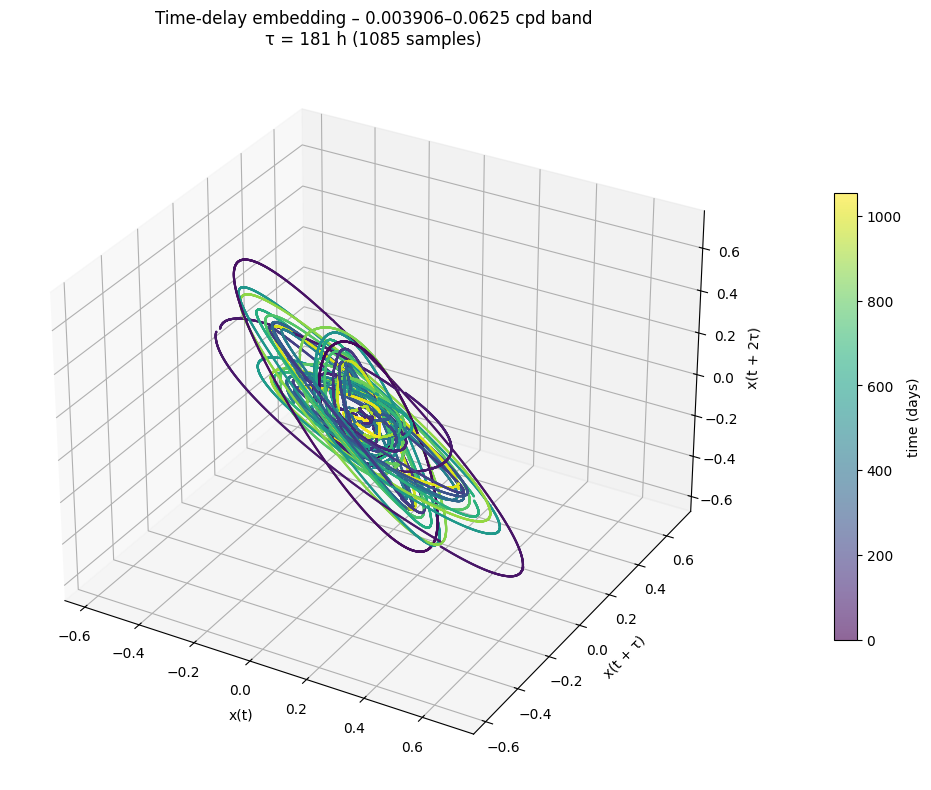

In [83]:
# ---- Time-delay embedding of the reconstructed band signal ----
# Embed x_band_signal in 3D using Takens' delay embedding theorem.
# Adjust `tau` (delay in samples) and `downsample` to taste.

from mpl_toolkits.mplot3d import Axes3D

# ---- parameters ----
tau = 1085          # delay in samples (144 × 10 min = 1 day for tidal; adjust as needed)
downsample = 1     # plot every Nth point (increase if too slow)

# build delay vectors: [x(t), x(t+tau), x(t+2*tau)]
s = x_band_signal
max_idx = len(s) - 2 * tau
X_emb = np.column_stack([s[:max_idx], s[tau:max_idx + tau], s[2*tau:max_idx + 2*tau]])
t_emb = t_days[:max_idx]

print(f"Delay τ = {tau} samples = {tau * dt / 3600:.1f} hours")
print(f"Embedding: {X_emb.shape[0]} points in 3D")

# ---- 3D scatter plot colored by time ----
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ds = downsample
sc = ax.scatter(
    X_emb[::ds, 0], X_emb[::ds, 1], X_emb[::ds, 2],
    c=t_emb[::ds], cmap='viridis', s=0.3, alpha=0.6,
)
ax.set_xlabel(f'x(t)')
ax.set_ylabel(f'x(t + τ)')
ax.set_zlabel(f'x(t + 2τ)')
ax.set_title(f'Time-delay embedding – {band_lo_cpd}–{band_hi_cpd} cpd band\n'
             f'τ = {tau * dt / 3600:.0f} h ({tau} samples)')

fig.colorbar(sc, ax=ax, label='time (days)', shrink=0.6, pad=0.1)
fig.tight_layout()
plt.show()

## Cell 4 – Ridge extraction

Key parameters:
- **`penalty`**: penalizes frequency jumps between time steps. High (20) = smooth ridges
  for slowly-varying tidal/creep signals. Low (0.5) = allows rapid frequency changes for transients.
- **`bw`**: after finding ridge *k*, zeros out `bw` rows around it before searching for ridge *k+1*.
  Use 4 for SSQ (energy is sharply concentrated) vs 15 for raw CWT (blurry).

In [84]:
ridge_idxs = extract_ridges(
    Tx, ssq_freqs,
    penalty=20.0,
    n_ridges=3,
    bw=2,            # 2 is standard for SSQ'd transforms (narrower energy)
    transform='cwt',  # 'cwt' = log-spaced scales (correct for both CWT & SSQ-CWT)
)

print(f"ridge_idxs shape: {ridge_idxs.shape}")  # (n_time, n_ridges)

# overlay ridges on scalogram
fig, ax = plt.subplots(figsize=(15, 6))
imshow(Tx, abs=1, cmap=cmap, ax=ax, fig=fig, show=0,
       yticks=scale_freq_cpd, ylabel='freq (cpd)',
       xticks=t_days, xlabel='time (days)',
       title='SSQ-CWT + extracted ridges')

colors_r = ['lime', 'cyan', 'magenta']
for k in range(ridge_idxs.shape[1]):
    # ridge_idxs are row indices into Tx; map to row positions for imshow
    ax.plot(np.arange(len(t_days)), ridge_idxs[:, k],
            color=colors_r[k], linewidth=0.6,
            label=f'ridge {k+1}', alpha=0.8)

ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

# print median frequencies of each ridge
for k in range(ridge_idxs.shape[1]):
    f_med = np.median(scale_freq_cpd[np.clip(ridge_idxs[:, k], 0, len(scale_freq_cpd)-1)])
    print(f"Ridge {k+1}: median = {f_med:.3f} cpd")

KeyboardInterrupt: 

## Cell 5 – Ridge-guided reconstruction

Use the ridge indices from `extract_ridges` as the center curve (`cc`) for `issq_cwt`.
This inverts only the energy along each ridge, reconstructing the dominant coherent modes
even if their frequency drifts over time.

In [ ]:
# ---- Invert ridges 1 and 2 ----
ridge_bw = 2  # rows on each side of the ridge center (narrow for SSQ)

# Stack ridge 0 and ridge 1 as two center curves
cc_r = np.column_stack([
    ridge_idxs[:, 0].astype(np.int32),
    ridge_idxs[:, 1].astype(np.int32),
])
cw_r = np.full_like(cc_r, ridge_bw)

x_ridges = issq_cwt(Tx, wavelet, cc=cc_r, cw=cw_r)
# shape: (3, n_time) = [ridge1, ridge2, residual]
x_ridge1 = np.real(x_ridges[0])
x_ridge2 = np.real(x_ridges[1])
x_ridge_resid = np.real(x_ridges[2])

# ridge frequencies over time
f_r1 = scale_freq_cpd[np.clip(ridge_idxs[:, 0], 0, len(scale_freq_cpd)-1)]
f_r2 = scale_freq_cpd[np.clip(ridge_idxs[:, 1], 0, len(scale_freq_cpd)-1)]

print(f"Ridge 1: median freq = {np.median(f_r1):.3f} cpd")
print(f"Ridge 2: median freq = {np.median(f_r2):.3f} cpd")

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

axes[0].plot(t_days, x, linewidth=0.4, color='k')
axes[0].set_ylabel('mm')
axes[0].set_title('Original')

axes[1].plot(t_days, f_r1, linewidth=0.4, color='lime')
axes[1].plot(t_days, f_r2, linewidth=0.4, color='cyan')
axes[1].set_ylabel('cpd')
axes[1].set_title('Ridge frequencies')
axes[1].legend(['Ridge 1', 'Ridge 2'], loc='upper right', fontsize=8)

axes[2].plot(t_days, x_ridge1, linewidth=0.4, color='lime')
axes[2].set_ylabel('mm')
axes[2].set_title(f'Ridge 1 (median {np.median(f_r1):.3f} cpd)')

axes[3].plot(t_days, x_ridge2, linewidth=0.4, color='cyan')
axes[3].set_ylabel('mm')
axes[3].set_title(f'Ridge 2 (median {np.median(f_r2):.3f} cpd)')

axes[4].plot(t_days, x_ridge_resid, linewidth=0.4, color='red')
axes[4].set_ylabel('mm')
axes[4].set_title('Residual (everything not on ridges 1 & 2)')

axes[-1].set_xlabel('time (days)')
fig.tight_layout()
plt.show()

In [ ]:
# ---- Mode-locked ridge inversion ----
# Use the statistical mode of each ridge's row index as a fixed center,
# so the reconstruction doesn't follow noisy frequency jumps.
from scipy.stats import mode

ridge_bw_fixed = 2  # rows on each side of the mode center

# Find the mode (most common row index) for each ridge
mode_r1 = int(mode(ridge_idxs[:, 0], keepdims=False).mode)
mode_r2 = int(mode(ridge_idxs[:, 1], keepdims=False).mode)

print(f"Ridge 1 mode: row {mode_r1} → {scale_freq_cpd[mode_r1]:.4f} cpd")
print(f"Ridge 2 mode: row {mode_r2} → {scale_freq_cpd[mode_r2]:.4f} cpd")

n_time = Tx.shape[1]
cc_fixed = np.column_stack([
    np.full(n_time, mode_r1, dtype=np.int32),
    np.full(n_time, mode_r2, dtype=np.int32),
])
cw_fixed = np.full_like(cc_fixed, ridge_bw_fixed)

x_fixed = issq_cwt(Tx, wavelet, cc=cc_fixed, cw=cw_fixed)
x_mode1 = np.real(x_fixed[0])
x_mode2 = np.real(x_fixed[1])
x_mode_resid = np.real(x_fixed[2])

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

axes[0].plot(t_days, x, linewidth=0.4, color='k')
axes[0].set_ylabel('mm')
axes[0].set_title('Original')

axes[1].plot(t_days, x_mode1, linewidth=0.4, color='lime')
axes[1].set_ylabel('mm')
axes[1].set_title(f'Mode-locked ridge 1: {scale_freq_cpd[mode_r1]:.4f} cpd ± {ridge_bw_fixed} rows')

axes[2].plot(t_days, x_mode2, linewidth=0.4, color='cyan')
axes[2].set_ylabel('mm')
axes[2].set_title(f'Mode-locked ridge 2: {scale_freq_cpd[mode_r2]:.4f} cpd ± {ridge_bw_fixed} rows')

axes[3].plot(t_days, x_mode_resid, linewidth=0.4, color='red')
axes[3].set_ylabel('mm')
axes[3].set_title('Residual')

axes[-1].set_xlabel('time (days)')
fig.tight_layout()
plt.show()

In [ ]:
# ---- AMI for mode-locked ridge 1 ----
def average_mutual_information(x, tau, n_bins):
    x1 = x[:-tau] if tau > 0 else x
    x2 = x[tau:]  if tau > 0 else x
    H_joint, _, _ = np.histogram2d(x1, x2, bins=n_bins)
    H_joint = H_joint / H_joint.sum()
    px = H_joint.sum(axis=1)
    py = H_joint.sum(axis=0)
    nz = H_joint > 0
    return np.sum(H_joint[nz] * np.log2(H_joint[nz] / (px[:, None] * py[None, :])[nz]))

s = x_mode1
sigma = np.std(s)
h_scott = 3.49 * sigma * len(s) ** (-1.0 / 3)
n_bins = max(int(np.ceil((s.max() - s.min()) / h_scott)), 8)
print(f"Scott's rule: h = {h_scott:.4f}, n_bins = {n_bins}")

tau_max = 500
taus = np.arange(0, tau_max + 1, 1)
ami_values = np.array([average_mutual_information(s, t, n_bins) for t in taus])
tau_hours = taus * 10.0 / 60.0

from scipy.signal import argrelmin
local_mins = argrelmin(ami_values, order=5)[0]
first_min_tau = local_mins[0] if len(local_mins) > 0 else None

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(tau_hours, ami_values, 'k-', linewidth=0.8)
ax.axhline(ami_values[0], color='grey', linestyle=':', linewidth=0.6,
           label=f'τ=0 → H(x) = {ami_values[0]:.3f} bits')
if first_min_tau is not None:
    ax.axvline(tau_hours[first_min_tau], color='red', linestyle='--', linewidth=0.8,
               label=f'1st min: τ = {tau_hours[first_min_tau]:.1f} h ({first_min_tau} samples)')
    ax.plot(tau_hours[first_min_tau], ami_values[first_min_tau], 'ro', ms=6)
ax.set_xlabel('time delay τ (hours)')
ax.set_ylabel('AMI (bits)')
ax.set_title(f'AMI – mode-locked ridge 1 ({scale_freq_cpd[mode_r1]:.4f} cpd)')
ax.legend()
fig.tight_layout()
plt.show()

if first_min_tau is not None:
    tau_embed = first_min_tau
    print(f"\n→ Suggested embedding delay: τ = {tau_embed} samples "
          f"= {tau_hours[tau_embed]:.1f} hours")
else:
    tau_embed = 43  # fallback
    print(f"\nNo local minimum found — using fallback τ = {tau_embed}")

In [ ]:
# ---- Time-delay embedding of mode-locked ridge 1 ----
from mpl_toolkits.mplot3d import Axes3D

tau = tau_embed    # from AMI first minimum
downsample = 1

s = x_mode1
max_idx = len(s) - 2 * tau
X_emb = np.column_stack([s[:max_idx], s[tau:max_idx + tau], s[2*tau:max_idx + 2*tau]])
t_emb = t_days[:max_idx]

print(f"Delay τ = {tau} samples = {tau * dt / 3600:.1f} hours")
print(f"Embedding: {X_emb.shape[0]} points in 3D")

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ds = downsample
sc = ax.scatter(
    X_emb[::ds, 0], X_emb[::ds, 1], X_emb[::ds, 2],
    c=t_emb[::ds], cmap='viridis', s=0.3, alpha=0.6,
)
ax.set_xlabel('x(t)')
ax.set_ylabel('x(t + τ)')
ax.set_zlabel('x(t + 2τ)')
ax.set_title(f'Time-delay embedding – mode-locked ridge 1 ({scale_freq_cpd[mode_r1]:.4f} cpd)\n'
             f'τ = {tau * dt / 3600:.0f} h ({tau} samples)')

fig.colorbar(sc, ax=ax, label='time (days)', shrink=0.6, pad=0.1)
fig.tight_layout()
plt.show()

Error: Error: ValueError: 'c' argument has 154031 elements, which is inconsistent with 'x' and 'y' with size 1000.
[31m---------------------------------------------------------------------------[39m
[31mValueError[39m                                Traceback (most recent call last)
[36mFile [39m[32m~/miniforge/envs/wavelet/lib/python3.12/site-packages/matplotlib/axes/_axes.py:4761[39m, in [36mAxes._parse_scatter_color_args[39m[34m(c, edgecolors, kwargs, xsize, get_next_color_func)[39m
[32m   4760[39m [38;5;28;01mtry[39;00m:  [38;5;66;03m# Is 'c' acceptable as PathCollection facecolors?[39;00m
[32m-> [39m[32m4761[39m     colors = [43mmcolors[49m[43m.[49m[43mto_rgba_array[49m[43m([49m[43mc[49m[43m)[49m
[32m   4762[39m [38;5;28;01mexcept[39;00m ([38;5;167;01mTypeError[39;00m, [38;5;167;01mValueError[39;00m) [38;5;28;01mas[39;00m err:

[36mFile [39m[32m~/miniforge/envs/wavelet/lib/python3.12/site-packages/matplotlib/colors.py:515[39m, in [36

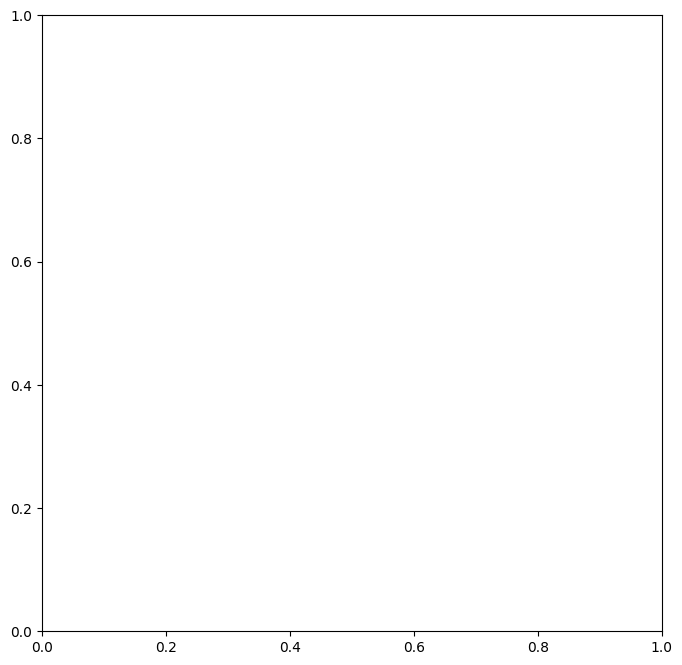

In [ ]:
# ---- 2D phase portrait: mode 1 vs mode 2 ----
fig, ax = plt.subplots(figsize=(8, 8))
m=2000
n=3000
sc = ax.scatter(
    x_mode1[m:n], x_mode2[m:n],
    c=t_days, cmap='viridis', s=0.3, alpha=0.5,
)
ax.set_xlabel(f'Mode 1 ({scale_freq_cpd[mode_r1]:.4f} cpd)', fontsize=11)
ax.set_ylabel(f'Mode 2 ({scale_freq_cpd[mode_r2]:.4f} cpd)', fontsize=11)
ax.set_title('Phase portrait: mode 1 vs mode 2')
ax.set_aspect('equal')
fig.colorbar(sc, ax=ax, label='time (days)', shrink=0.8)
fig.tight_layout()
plt.show()

### M2 tidal component (~2 cpd)

In [ ]:
# M2 tidal at ~1.93 cpd
target_m2 = 1.932
row_m2 = np.argmin(np.abs(ssq_freqs - target_m2 / 86400.0))
offset_m2 = row_m2 / nf
print(f"M2 (~1.93 cpd): row {row_m2}/{nf}, offset = {offset_m2:.4f}, "
      f"actual freq = {freq_cpd[row_m2]:.3f} cpd")

plt.figure(figsize=(14, 5))
Cs_m2, fb_m2 = lin_band(Tx, slope=0, offset=offset_m2, bw=bw_frac)
plt.title('lin_band: M2 tidal band')
plt.show()

x_m2 = issq_cwt(Tx, wavelet, cc=Cs_m2, cw=fb_m2)
x_m2_signal = np.real(x_m2[0])

plt.figure(figsize=(14, 3))
plt.plot(t_days, x_m2_signal, linewidth=0.5, color='coral')
plt.xlabel('time (days)')
plt.ylabel('displacement (mm)')
plt.title('Reconstructed M2 tidal component (~1.93 cpd)')
plt.tight_layout()
plt.show()

## Cell 6 – Ridge-guided reconstruction

For **non-stationary** components whose frequency changes over time,
use the ridge indices directly as `cc` (center curve) for `issq_cwt`.
This tracks the mode even if its frequency drifts.

In [ ]:
# Use ridge 0 (the strongest) as center curve
cc_ridge0 = ridge_idxs[:, 0].astype(np.int32)

# constant bandwidth: 3 rows on each side (narrow for SSQ)
cw_ridge0 = np.full_like(cc_ridge0, 3)

x_ridge0 = issq_cwt(Tx, wavelet, cc=cc_ridge0, cw=cw_ridge0)
x_ridge0_signal = np.real(x_ridge0[0])

# ridge frequency over time
f_ridge0 = freq_cpd[cc_ridge0]

fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
axes[0].plot(t_days, f_ridge0, linewidth=0.5, color='green')
axes[0].set_ylabel('ridge freq (cpd)')
axes[0].set_title('Ridge 1: instantaneous frequency')

axes[1].plot(t_days, x_ridge0_signal, linewidth=0.5, color='green')
axes[1].set_ylabel('displacement (mm)')
axes[1].set_xlabel('time (days)')
axes[1].set_title('Ridge 1: reconstructed component')

fig.tight_layout()
plt.show()

## Cell 7 – Multi-component separation

Extract three broad frequency bands and reconstruct each:

| Band       | Range (cpd) | Geophysical meaning          |
|------------|-------------|------------------------------|
| Tidal      | 0.8 – 2.2   | O1, K1, M2, S2 tides         |
| Multi-day  | 0.05 – 0.5  | Slow-slip, weather, storms   |
| Seasonal   | < 0.01      | Long-term creep trend         |

In [ ]:
def make_band_cc_cw(ssq_freqs, freq_lo_hz, freq_hi_hz, n_time):
    """Create constant cc/cw arrays for a horizontal frequency band."""
    row_lo = np.argmin(np.abs(ssq_freqs - freq_lo_hz))
    row_hi = np.argmin(np.abs(ssq_freqs - freq_hi_hz))
    if row_lo > row_hi:
        row_lo, row_hi = row_hi, row_lo
    center = (row_lo + row_hi) // 2
    half_bw = (row_hi - row_lo) // 2
    cc = np.full(n_time, center, dtype=np.int32)
    cw = np.full(n_time, half_bw, dtype=np.int32)
    return cc, cw

n_time = Tx.shape[1]

# Tidal band: 0.8–2.2 cpd
cc_tidal, cw_tidal = make_band_cc_cw(ssq_freqs, 0.8/86400, 2.2/86400, n_time)

# Multi-day band: 0.05–0.5 cpd
cc_multi, cw_multi = make_band_cc_cw(ssq_freqs, 0.05/86400, 0.5/86400, n_time)

# Seasonal band: 0.001–0.01 cpd
cc_season, cw_season = make_band_cc_cw(ssq_freqs, 0.001/86400, 0.01/86400, n_time)

# Stack all three bands for a single issq_cwt call
cc_all = np.column_stack([cc_tidal, cc_multi, cc_season])  # (n_time, 3)
cw_all = np.column_stack([cw_tidal, cw_multi, cw_season])  # (n_time, 3)

x_modes = issq_cwt(Tx, wavelet, cc=cc_all, cw=cw_all)
# shape: (4, n_time) = [tidal, multi-day, seasonal, residual]
print(f"Reconstructed modes shape: {x_modes.shape}")

x_tidal = np.real(x_modes[0])
x_multi = np.real(x_modes[1])
x_season = np.real(x_modes[2])
x_resid = np.real(x_modes[3])

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(15, 14), sharex=True)

axes[0].plot(t_days, x, linewidth=0.4, color='k')
axes[0].set_ylabel('mm')
axes[0].set_title('Original signal')

axes[1].plot(t_days, x_tidal, linewidth=0.4, color='steelblue')
axes[1].set_ylabel('mm')
axes[1].set_title('Tidal (0.8–2.2 cpd)')

axes[2].plot(t_days, x_multi, linewidth=0.4, color='darkorange')
axes[2].set_ylabel('mm')
axes[2].set_title('Multi-day (0.05–0.5 cpd)')

axes[3].plot(t_days, x_season, linewidth=0.4, color='green')
axes[3].set_ylabel('mm')
axes[3].set_title('Seasonal (< 0.01 cpd)')

axes[4].plot(t_days, x_resid, linewidth=0.4, color='red')
axes[4].set_ylabel('mm')
axes[4].set_title('Residual')

axes[-1].set_xlabel('time (days)')
fig.suptitle('SSQ-CWT multi-component separation – XMR1', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()

In [ ]:
# Quality check: how much of the signal is captured?
x_sum = x_tidal + x_multi + x_season
residual_check = x - x_sum

def mad_rms(a):
    """Median absolute deviation and RMS."""
    return np.median(np.abs(a)), np.sqrt(np.mean(a**2))

mad_orig, rms_orig = mad_rms(x)
mad_res, rms_res = mad_rms(residual_check)

print(f"Original signal  –  MAD: {mad_orig:.4f}  RMS: {rms_orig:.4f}")
print(f"Residual (x - sum of 3 modes) – MAD: {mad_res:.4f}  RMS: {rms_res:.4f}")
print(f"Variance explained: {1 - (rms_res**2 / rms_orig**2):.1%}")

## Cell 8 – Frequency-band summary

| Band     | cpd range   | Hz range                  | Geophysical signal              |
|----------|-------------|---------------------------|---------------------------------|
| Tidal    | 0.8 – 2.2   | 9.3e-6 – 2.5e-5           | O1, K1, M2, S2 earth tides     |
| Multi-day| 0.05 – 0.5  | 5.8e-7 – 5.8e-6           | Slow-slip events, weather       |
| Seasonal | < 0.01      | < 1.2e-7                  | Long-term fault creep trend     |

### Next steps
- Feed the **tidal** component to LastWave WTMM for singularity analysis of tidal modulation
- Feed the **residual** to WTMM to characterize transient events (sharp singularities = earthquakes)
- Apply this pipeline across the full creepmeter network for multi-station comparison